# Pension Model Results Analysis

This notebook analyzes the run selected by `RUN_TAG` in `Results/Runs/`. It leads with stochastic risk metrics (asset-exhaustion probabilities, threshold risk, distribution fans), then aggregate dynamics, per-plan detail, and finally baseline/descriptive context and validation. Figures are displayed in the notebook and are not saved to disk.

A note on simulation structure: as of 2026-06-10, the Python asset simulation uses **common market shocks** — simulation column *n* is the same market history for every plan — so cross-plan aggregate distributions (fans, tail percentiles) are meaningful. If the loaded outputs predate this change (or are R outputs with independent per-plan draws), aggregate bands understate risk; the load cell below checks the flag.

In [26]:
from pathlib import Path
import sys

# results_analysis.py is co-located with this notebook
_here = Path.cwd().resolve()
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import results_analysis as ra

ROOT = ra.find_project_root()
RUN_TAG = ra.latest_run_tag(ROOT)   # newest YYYYMMDD_N run; set a tag explicitly to pin one
print(f"RUN_TAG = {RUN_TAG!r}")
RESULT_SOURCE = "auto"    # "auto" detects from the run folder; or set "rdata" (R) / "parquet" (Python)
GRAPH_YEARS = 15          # horizon for forecast-style figures; risk metrics use the full projection
RUN_DIR = ra.run_dir(ROOT, RUN_TAG)
if RESULT_SOURCE == "auto":
    RESULT_SOURCE = ra.detect_result_source(ROOT, RUN_TAG)
print(f"RESULT_SOURCE = {RESULT_SOURCE!r}")

plt.style.use("seaborn-v0_8-whitegrid")
print(ROOT)
print(RUN_DIR)

RUN_TAG = '20260731_1'
RESULT_SOURCE = 'parquet'
C:\Users\ncomati\Massachusetts Institute of Technology\MIT Golub Center for Finance and Policy - Documents\Research and Education\Projects\State and Local Pension
C:\Users\ncomati\Massachusetts Institute of Technology\MIT Golub Center for Finance and Policy - Documents\Research and Education\Projects\State and Local Pension\Results\Runs\20260731_1


## Run Inventory

The first table counts deterministic A/L and asset-simulation statuses in the selected run manifest. The second table lists the plan-level manifest records, so missing or skipped outputs can be identified before interpreting the results.

In [27]:
manifest = ra.load_manifest(ROOT, RUN_TAG)
status_counts = manifest.groupby(["detal_status", "asset_status"]).size().rename("count").reset_index()
display(status_counts)
display(manifest.sort_values(["asset_status", "detal_status", "plan"]))

,detal_status,asset_status,count
0,valid,saved,1


,plan,detal_status,asset_status,skip_reason,detAL_file,asset_file,run_tag,detal_run_tag,num_sim,scenario,parquet_dir,timestamp,elapsed_s
0,TX108,valid,saved,NaN,C:\Users\ncomati\Massachusetts Institute of Te...,C:\Users\ncomati\Massachusetts Institute of Te...,20260731_1,20260731_1,10000,NaN,C:\Users\ncomati\Massachusetts Institute of Te...,2026-07-31 10:55:18,35.66


## Select And Read Simulation Outputs

`RUN_TAG` selects the folder under `Results/Runs/`. `RESULT_SOURCE` sets the input format: `"auto"` (default) detects it from the run folder contents, or set `"rdata"` (R run outputs) / `"parquet"` (Python run outputs) explicitly. `SELECTED_PLANS = None` reads every plan in that run with an asset-simulation result; set it to a list such as `["CA10", "AZ06"]` for a faster subset.

For R result files (`RESULT_SOURCE = "rdata"`), the notebook creates clean `*_analysis.RData` companion files when needed. The cell also checks the common-market-shock flag saved with each plan's asset output: aggregate distribution bands later in the notebook are only meaningful when all plans share one shock matrix.

In [28]:
SELECTED_PLANS = None
# SELECTED_PLANS = ["CA10", "AZ06", "PA93"]

if RESULT_SOURCE == "rdata":
    ra.prepare_analysis_exports(ROOT, RUN_TAG, plans=SELECTED_PLANS, overwrite=False, progress=True)

results = ra.load_run_results(ROOT, RUN_TAG, plans=SELECTED_PLANS, progress=True, source=RESULT_SOURCE)
print(f"Using {len(results)} plans with asset simulations in the selected run.")

# Common-shock flag check (see header note)
_common = {p: str(r.scalars.get("common_market_shocks", "")).strip().lower() == "true"
           for p, r in results.items()}
if all(_common.values()):
    seeds = {str(r.scalars.get("market_seed", "")) for r in results.values()}
    print(f"All plans share common market shocks (market_seed = {sorted(seeds)}). Aggregate fans are valid.")
else:
    missing = sorted(p for p, ok in _common.items() if not ok)
    print(f"[warn] {len(missing)} plan(s) lack the common-shock flag: {missing}")
    print("[warn] Aggregate distribution bands will UNDERSTATE risk (independent draws cancel across plans).")

ppd = ra.load_ppd(ROOT)
print(f"PPD reference data: {ppd.shape[0]} rows")

analysis_inventory = pd.DataFrame(
    {
        "plan": plan,
        "ppid": result.ppid,
        "plan_year": result.plan_year,
        "n_years": result.n_years,
        "n_simulations": result.n_simulations,
        "file": str(result.file_path),
    }
    for plan, result in results.items()
)
display(analysis_inventory)

[1/40] loading AZ06
[2/40] loading AZ127
[3/40] loading CA10
[4/40] loading CA111
[5/40] loading CA144
[6/40] loading CA43
[7/40] loading CA97
[8/40] loading CA98
[9/40] loading DC20
[10/40] loading FL26
[11/40] loading GA27
[12/40] loading GA28
[13/40] loading IL32
[14/40] loading IL33
[15/40] loading IL34
[16/40] loading IN37
[17/40] loading LA130
[18/40] loading LA163
[19/40] loading LA44
[20/40] loading MA50
[21/40] loading MA51
[22/40] loading ME47
[23/40] loading MI53
[24/40] loading MO175
[25/40] loading MO64
[26/40] loading ND82
[27/40] loading NJ71
[28/40] loading NJ73
[29/40] loading NM74
[30/40] loading NY78
[31/40] loading NY83
[32/40] loading OH88
[33/40] loading OK134
[34/40] loading OR91
[35/40] loading PA92
[36/40] loading PA93
[37/40] loading RI96
[38/40] loading SC100
[39/40] loading SC99
[40/40] loading TX108
Using 40 plans with asset simulations in the selected run.
All plans share common market shocks (market_seed = ['123']). Aggregate fans are valid.
PPD reference

,plan,ppid,plan_year,n_years,n_simulations,file
0,AZ06,6,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
1,AZ127,127,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
2,CA10,10,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
3,CA111,111,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
4,CA144,144,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
5,CA43,43,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
6,CA97,97,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
7,CA98,98,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
8,DC20,20,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...
9,FL26,26,2022,35,10000,C:\Users\ncomati\Massachusetts Institute of Te...


## Metric Construction

This code-only section builds the plan-level variables used throughout: official funded ratios, unfunded liabilities relative to payroll, contribution rates, active-to-retired ratios, first asset-exhaustion years per simulation path, aggregate per-path balance sheets, and FRED fetch helpers. `N_PROJ` is the usable projection length (the final placeholder year with zero AAL is dropped).

In [31]:
import json as _json
import os
import re
from urllib.parse import urlencode
from urllib.request import urlopen

# Population growth is a SIMULATION setting, not an analysis choice: the engine
# refills the workforce at this rate every year (engine/run_plan.py). It is read
# from the run rather than retyped here, because a hand-copied constant silently
# stops matching the moment the engine's value changes.
#
# Runs produced before 2026-07-31 do not carry it -- it was not saved with the
# results -- so those fall back to the value the engine used at the time, and the
# fallback announces itself rather than passing silently.
MODEL_POPULATION_GROWTH_FALLBACK = 0.01

_pop_values = {float(r.scalars["PopulationGrowth"])
               for r in results.values() if r.scalars.get("PopulationGrowth") is not None}
if not _pop_values:
    MODEL_POPULATION_GROWTH = MODEL_POPULATION_GROWTH_FALLBACK
    print(f"[note] this run predates 2026-07-31 and does not record PopulationGrowth; "
          f"using the engine value of {MODEL_POPULATION_GROWTH} for GDP projection")
elif len(_pop_values) > 1:
    raise ValueError(f"plans in this run disagree on PopulationGrowth: {sorted(_pop_values)}")
else:
    MODEL_POPULATION_GROWTH = _pop_values.pop()

# The disability payout rate is likewise a choice, and is what the paired
# sensitivity varies. Reported here so a run states which side of that pair it is.
_dis_values = {float(r.scalars["DisabilityPayoutRate"])
               for r in results.values() if r.scalars.get("DisabilityPayoutRate") is not None}
DISABILITY_PAYOUT_RATE = _dis_values.pop() if len(_dis_values) == 1 else None
if _dis_values:
    print(f"[note] plans in this run use different disability rates: {sorted(_dis_values)}")
BASE_YEAR = int(min(result.plan_year for result in results.values()))

# THE TWO HORIZONS ARE NOT THE SAME, AND THAT IS A PROPERTY OF THE ENGINE.
#
# The saved matrices are all 35 rows tall, but they are not all filled to 35.
# The liability loop in engine/core.py runs `for t in range(1, Nyear)` and
# writes to index t-1, so AAL, cash_inflows, cash_outflows and NormalCost hold
# 34 real values (the base year plus 33 projected years) and their final row is
# never written -- it is zero for all 40 plans. The asset loop in
# asset_simulation.py is separate: it writes assets[t+1] for t = 0..33, so
# Assets holds 35 real values, one year further out than the liability side.
#
#   N_PROJ      = 34 usable liability rows  -> BASE_YEAR .. BASE_YEAR + 33
#   MAX_OFFSET  = 34 projected asset years  -> BASE_YEAR + 1 .. BASE_YEAR + 34
#
# Exhaustion is an asset event, so it is measured over the full asset horizon.
# Anything built on the funding ratio needs AAL and so stops a year earlier.
# Horizons are named by fiscal year throughout, so the difference is visible in
# the column names instead of hidden behind a "years ahead" count.
N_PROJ = min(r.n_years for r in results.values()) - 1
MAX_OFFSET = min(r.n_years for r in results.values()) - 1

EXHAUST_HORIZONS = (10, 20, 30, MAX_OFFSET)
EXHAUST_YEARS = tuple(BASE_YEAR + h for h in EXHAUST_HORIZONS)
EXH_COLS = {h: f"prob_exhaust_by_{BASE_YEAR + h}" for h in EXHAUST_HORIZONS}
EXH_COL_MAX = EXH_COLS[MAX_OFFSET]
LIABILITY_LAST_YEAR = BASE_YEAR + N_PROJ - 1
ASSET_LAST_YEAR = BASE_YEAR + MAX_OFFSET

TABLE1_METRICS = [
    ("Assets / liabilities", "assets_liabilities", "ActLiabilities_GASB"),
    ("Unfunded liabilities / payroll", "unfunded_liabilities_payroll", "payroll"),
    ("Total pension contributions / payroll", "total_pension_contributions_payroll", "payroll"),
    ("Active members / retired members", "active_retired_members", "retired_members"),
]
# "Projected active member growth" was removed from this table on 2026-07-31.
# It was not a plan characteristic: it is the model's own hardcoded workforce
# growth assumption, (1 + MODEL_POPULATION_GROWTH) ** 30 - 1, identical for
# every plan, so it reported a mean of 0.3478 and a standard deviation of
# exactly zero while sitting in a table of measured quantities. The assumption
# itself is stated in the markdown above the table.


def finite_numeric(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.where(np.isfinite(values))


def num_col(frame, name):
    if name not in frame.columns:
        return pd.Series(np.nan, index=frame.index, dtype="float64")
    return finite_numeric(frame[name])


def safe_ratio(numerator, denominator):
    numerator = finite_numeric(numerator)
    denominator = finite_numeric(denominator)
    return (numerator / denominator).where(denominator > 0)


def first_available(frame, names):
    out = pd.Series(np.nan, index=frame.index, dtype="float64")
    for name in names:
        if name in frame.columns:
            out = out.fillna(pd.to_numeric(frame[name], errors="coerce"))
    return out


def add_core_metrics(frame):
    data = frame.copy()
    data["assets_liabilities"] = safe_ratio(num_col(data, "ActAssets_GASB"), num_col(data, "ActLiabilities_GASB"))
    data["unfunded_liabilities"] = num_col(data, "ActLiabilities_GASB") - num_col(data, "ActAssets_GASB")
    data["unfunded_liabilities_payroll"] = safe_ratio(data["unfunded_liabilities"], num_col(data, "payroll"))
    data["total_pension_contributions_payroll"] = safe_ratio(num_col(data, "contrib_tot"), num_col(data, "payroll"))
    data["retired_members"] = first_available(data, ["beneficiaries_tot", "beneficiaries_ServiceRetirees"])
    data["active_retired_members"] = safe_ratio(num_col(data, "actives_tot"), data["retired_members"])
    data["official_funded_ratio"] = data["assets_liabilities"]
    data["liability_billion"] = num_col(data, "ActLiabilities_GASB") / 1_000_000
    data["unfunded_liability_billion"] = data["unfunded_liabilities"] / 1_000_000
    data["contribution_rate"] = data["total_pension_contributions_payroll"]
    return data


def build_plan_metrics(results):
    rows = []
    for plan, result in sorted(results.items()):
        row = result.planinfo.iloc[0].to_dict() if result.planinfo is not None else {}
        row.update({
            "plan": plan,
            "ppid": result.ppid,
            "model_aal": result.scalars.get("Model_AAL"),
            "cafr_aal": result.scalars.get("CAFR_AAL"),
            "percent_difference": result.scalars.get("Percent_difference"),
            "n_simulations": result.n_simulations,
        })
        rows.append(row)
    data = add_core_metrics(pd.DataFrame(rows))
    data["model_aal_billion"] = pd.to_numeric(data["model_aal"], errors="coerce") / 1_000_000_000
    data["cafr_aal_billion"] = pd.to_numeric(data["cafr_aal"], errors="coerce") / 1_000_000_000
    data["percent_difference"] = pd.to_numeric(data["percent_difference"], errors="coerce")
    return data


def weighted_mean_sd(values, weights):
    values = finite_numeric(values).to_numpy(dtype="float64")
    weights = finite_numeric(weights).to_numpy(dtype="float64")
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not mask.any():
        return np.nan, np.nan, 0
    values = values[mask]
    weights = weights[mask]
    mean = np.average(values, weights=weights)
    sd = np.sqrt(np.average((values - mean) ** 2, weights=weights))
    return mean, sd, int(mask.sum())


def table1_summary(frame):
    rows = []
    for label, value_col, weight_col in TABLE1_METRICS:
        values = finite_numeric(frame[value_col])
        unweighted = values[np.isfinite(values)]
        weighted_mean, weighted_sd, weighted_obs = weighted_mean_sd(values, frame.get(weight_col))
        rows.append({
            "metric": label,
            "unweighted_mean": unweighted.mean(),
            "unweighted_sd": unweighted.std(ddof=1),
            "unweighted_obs": int(unweighted.shape[0]),
            "weighted_mean": weighted_mean,
            "weighted_sd": weighted_sd,
            "weighted_obs": weighted_obs,
        })
    return pd.DataFrame(rows)


def historical_official_funding(ppd, ppids):
    hist = ppd.loc[ppd["ppd_id"].isin(ppids)].copy()
    hist["fy"] = pd.to_numeric(hist["fy"], errors="coerce")
    hist["official_funded_ratio"] = safe_ratio(hist["ActAssets_GASB"], hist["ActLiabilities_GASB"])
    hist["liability_weight"] = num_col(hist, "ActLiabilities_GASB")
    rows = []
    for fy, group in hist.groupby("fy"):
        values = group["official_funded_ratio"]
        weights = group["liability_weight"]
        weighted_mean, _, weighted_obs = weighted_mean_sd(values, weights)
        rows.append({
            "fy": fy,
            "equal_weighted": values.mean(),
            "liability_weighted": weighted_mean,
            "observations": int(values.notna().sum()),
            "weighted_observations": weighted_obs,
        })
    return pd.DataFrame(rows).sort_values("fy")


def first_exhaustion_offsets(result):
    """Offset from the base year of the first projected year with zero assets.

    Returns NaN for paths that never exhaust. Offsets run 1..MAX_OFFSET, i.e.
    BASE_YEAR + 1 .. ASSET_LAST_YEAR, because assets are projected one year
    beyond the liability side (see the horizon note at the top of this cell).
    """
    assets = result.matrix("Assets").to_numpy(dtype="float64")
    zero = assets[1:, :] <= 0
    any_hit = zero.any(axis=0)
    first_hit = zero.argmax(axis=0) + 1.0
    return np.where(any_hit, first_hit, np.nan)


def years_insolvent_mean(result, horizon=None):
    # Average number of projection years with zero assets, across paths
    assets = result.matrix("Assets").to_numpy(dtype="float64")
    n = assets.shape[0] if horizon is None else min(horizon + 1, assets.shape[0])
    return float(np.mean((assets[1:n, :] <= 0).sum(axis=0)))


def exhaustion_plan_summary(results, plan_metrics, horizons=EXHAUST_HORIZONS):
    metric_lookup = plan_metrics.set_index("plan")
    rows = []
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        row = {
            "plan": plan,
            "liability_billion": metric_lookup.loc[plan, "liability_billion"],
            "official_funded_ratio": metric_lookup.loc[plan, "official_funded_ratio"],
            "unfunded_liabilities_payroll": metric_lookup.loc[plan, "unfunded_liabilities_payroll"],
            "contribution_rate": metric_lookup.loc[plan, "contribution_rate"],
            "prob_no_exhaustion": np.nanmean(np.isnan(offsets) | (offsets > MAX_OFFSET)),
        }
        for horizon in horizons:
            col = f"prob_exhaust_by_{result.plan_year + horizon}"
            row[col] = np.nanmean(offsets <= horizon)
            row[f"expected_liability_exhaust_by_{result.plan_year + horizon}_billion"] = (
                row["liability_billion"] * row[col])
        exhausted = offsets[np.isfinite(offsets)]
        row["median_exhaustion_year_if_exhausted"] = np.nan if exhausted.size == 0 else int(result.plan_year + np.nanmedian(exhausted))
        row["mean_years_insolvent"] = years_insolvent_mean(result, horizon=N_PROJ)
        rows.append(row)
    return pd.DataFrame(rows)


def liability_weighted_exhaustion_bins(results, plan_metrics):
    edges = [(1, 10), (11, 20), (21, 30), (31, MAX_OFFSET)]
    bins = [(lo, hi, f"{BASE_YEAR + lo}-{BASE_YEAR + hi}") for lo, hi in edges]
    never_label = f"Never by {ASSET_LAST_YEAR}"
    metric_lookup = plan_metrics.set_index("plan")
    rows = []
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        liability = metric_lookup.loc[plan, "liability_billion"]
        for low, high, label in bins:
            prob = np.nanmean((offsets >= low) & (offsets <= high))
            rows.append({"bin": label, "plan": plan, "probability": prob, "liability_billion": liability, "expected_liability_billion": liability * prob})
        prob_never = np.nanmean(np.isnan(offsets) | (offsets > MAX_OFFSET))
        rows.append({"bin": never_label, "plan": plan, "probability": prob_never, "liability_billion": liability, "expected_liability_billion": liability * prob_never})
    data = pd.DataFrame(rows)
    total_liabilities = plan_metrics["liability_billion"].sum()
    summary = data.groupby("bin", as_index=False)["expected_liability_billion"].sum()
    summary["liability_share"] = summary["expected_liability_billion"] / total_liabilities
    order = [label for _, _, label in bins] + [never_label]
    summary["bin"] = pd.Categorical(summary["bin"], categories=order, ordered=True)
    # Bin widths are NOT equal -- the first three span ten years each and the last
    # spans four, because the projection ends at MAX_OFFSET rather than on a round
    # number. Comparing bin totals therefore compares different-length windows and
    # makes the final bin look small when its per-year rate is the highest of all.
    # The per-year column is the comparable one.
    widths = {label: hi - lo + 1 for lo, hi, label in bins}
    summary["years_in_bin"] = summary["bin"].astype(str).map(widths)
    summary["expected_liability_per_year_billion"] = (
        summary["expected_liability_billion"] / summary["years_in_bin"])
    return summary.sort_values("bin")


def liability_weighted_exhaustion_by_year(results, plan_metrics):
    """Expected liability first exhausting in EACH projected year.

    No binning: one row per fiscal year, so no window-width choice can distort
    the shape. Plans are weighted by base-year GASB liability, and the value is
    that liability times the probability that the plan first exhausts that year.
    The mass that never exhausts is returned separately, since it belongs to no
    year and cannot be drawn on the same axis honestly.
    """
    lookup = plan_metrics.set_index("plan")["liability_billion"]
    years = np.arange(1, MAX_OFFSET + 1)
    expected = np.zeros(len(years), dtype="float64")
    never = 0.0
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        liability = lookup.get(plan, np.nan)
        if not np.isfinite(liability):
            continue
        for j, horizon in enumerate(years):
            expected[j] += liability * np.nanmean(offsets == horizon)
        never += liability * np.nanmean(np.isnan(offsets) | (offsets > MAX_OFFSET))
    total = float(lookup.sum())
    frame = pd.DataFrame({
        "year": BASE_YEAR + years,
        "expected_liability_billion": expected,
        "liability_share": expected / total,
    })
    return frame, never, total


def liability_weighted_exhausted_by_year(results, plan_metrics):
    """Expected liability that HAS exhausted assets by each projected year.

    The cumulative counterpart of `liability_weighted_exhaustion_by_year`: that
    one counts a plan once, in the year it first runs out; this one counts it in
    every year from then on, so it is a stock rather than a flow.

    The two are the same information arranged differently, and this one is also
    a rescaling of the liability-weighted curve in the exhaustion-CDF figure
    below -- that curve as a probability, this one multiplied by total
    liabilities to give dollars.

    Verified on this run: no path ever returns to positive assets after reaching
    zero (0 recoveries out of 132,127 exhausting paths), so "has exhausted by
    year t" and "is exhausted in year t" are the same series. If a future engine
    change ever lets a plan recover, they separate and this function measures
    the first of the two.
    """
    lookup = plan_metrics.set_index("plan")["liability_billion"]
    years = np.arange(1, MAX_OFFSET + 1)
    expected = np.zeros(len(years), dtype="float64")
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        liability = lookup.get(plan, np.nan)
        if not np.isfinite(liability):
            continue
        for j, horizon in enumerate(years):
            expected[j] += liability * np.nanmean(offsets <= horizon)
    total = float(lookup.sum())
    never = total - float(expected[-1])
    frame = pd.DataFrame({
        "year": BASE_YEAR + years,
        "expected_liability_billion": expected,
        "liability_share": expected / total,
    })
    return frame, never, total


def exhaustion_cdf(results, plan_metrics, max_year=35):
    # P(first exhaustion <= y) per plan, plus the liability-weighted average curve
    lookup = plan_metrics.set_index("plan")["liability_billion"]
    horizons = np.arange(1, max_year + 1)
    per_plan = {}
    for plan, result in sorted(results.items()):
        offsets = first_exhaustion_offsets(result)
        per_plan[plan] = np.array([np.nanmean(offsets <= h) for h in horizons])
    cdf = pd.DataFrame(per_plan, index=pd.Index(horizons, name="years_ahead"))
    weights = lookup.reindex(cdf.columns).to_numpy(dtype="float64")
    weights = np.where(np.isfinite(weights), weights, 0.0)
    weighted = cdf.to_numpy() @ weights / weights.sum()
    return cdf, pd.Series(weighted, index=cdf.index, name="liability_weighted")


def aggregate_matrix(results, matrix_name):
    """Sum one matrix across plans, path by path.

    Uses a plain sum, not nansum: a NaN in any plan must propagate into the
    aggregate rather than being silently treated as a zero contribution. The
    check below turns that into an explicit error naming the plans involved.
    """
    arrays = [result.matrix(matrix_name).to_numpy(dtype="float64") for result in results.values()]
    min_years = min(arr.shape[0] for arr in arrays)
    min_sims = min(arr.shape[1] for arr in arrays)
    clipped = [arr[:min_years, :min_sims] for arr in arrays]
    bad = [plan for plan, arr in zip(results, clipped) if np.isnan(arr).any()]
    if bad:
        raise ValueError(
            f"{matrix_name} contains NaN for {len(bad)} plan(s): {bad}. "
            "Aggregating would hide it; investigate the run before continuing.")
    return np.sum(np.stack(clipped, axis=0), axis=0)


def aggregate_paths(results):
    # Per-path aggregate balance sheet. Distributionally meaningful only with
    # common market shocks across plans (checked at load time above).
    assets = aggregate_matrix(results, "Assets")
    aal = aggregate_matrix(results, "AAL")
    first = next(iter(results.values()))
    years = np.asarray(first.years(assets.shape[0]))
    valid = np.any(np.isfinite(aal) & (aal > 0), axis=1)
    return years[valid], assets[valid, :], aal[valid, :]


def fan_table(years, matrix, quantiles=(0.05, 0.25, 0.50, 0.75, 0.95)):
    out = {"year": [int(y) for y in years], "mean": np.nanmean(matrix, axis=1)}
    for q in quantiles:
        out[f"q{int(round(q * 100)):02d}"] = np.nanquantile(matrix, q, axis=1)
    return pd.DataFrame(out)


def plot_fan(ax, fan, label, color="tab:blue"):
    x = fan["year"].to_numpy()
    ax.fill_between(x, fan["q05"], fan["q95"], alpha=0.12, color=color, label="5-95 pct")
    ax.fill_between(x, fan["q25"], fan["q75"], alpha=0.22, color=color, label="25-75 pct")
    ax.plot(x, fan["mean"], color=color, label=f"{label} mean")
    ax.plot(x, fan["q50"], color=color, linestyle="--", linewidth=1, label=f"{label} median")


# --- FRED helpers (used by the GDP and AAA sections; both skip gracefully) ---
# Read from the environment first, then from the untracked `.env` file at the
# project root. `.env` is gitignored, so the key never reaches GitHub; put it
# there once and every session picks it up with nothing to set by hand.
# See `.env.example` for the format.
FRED_API_KEY = ra.local_setting("FRED_API_KEY")
FRED_API_BASE_URL = "https://api.stlouisfed.org/fred/series/observations"


def fetch_fred_series(series_id, api_key=None, observation_start="1900-01-01"):
    api_key = api_key or FRED_API_KEY
    if not api_key:
        raise ValueError("FRED_API_KEY is not set (notebook variable or environment variable).")
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json",
              "observation_start": observation_start}
    with urlopen(f"{FRED_API_BASE_URL}?{urlencode(params)}", timeout=30) as response:
        payload = _json.load(response)
    if "observations" not in payload:
        raise ValueError(f"FRED API did not return observations for {series_id}: {payload.get('error_message', payload)}")
    data = pd.DataFrame(payload["observations"])
    if data.empty:
        return pd.DataFrame(columns=["date", series_id])
    out = data[["date", "value"]].rename(columns={"value": series_id})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out[series_id] = pd.to_numeric(out[series_id].replace(".", np.nan), errors="coerce")
    return out.dropna(subset=["date", series_id]).sort_values("date")


def try_fetch_fred(series_id):
    """Fetch a FRED series, or return None after saying loudly that it failed.

    Sections built on FRED produce nothing at all without a key, so the failure
    is announced rather than mentioned: on a machine without FRED_API_KEY set,
    a quiet one-line note is easy to scroll past and leaves the notebook
    looking complete when two whole sections are missing.
    """
    try:
        return fetch_fred_series(series_id)
    except Exception as exc:
        bar = "!" * 78
        print(bar)
        print(f"SECTION SKIPPED -- FRED series {series_id} could not be fetched.")
        print(f"  reason : {exc}")
        print("  effect : every figure and table in this section is MISSING, not empty.")
        print("  fix    : put FRED_API_KEY in the .env file at the project root")
        print("           (copy .env.example to .env and fill it in), then rerun this cell.")
        print(bar)
        return None


plan_metrics = build_plan_metrics(results)
exhaustion = exhaustion_plan_summary(results, plan_metrics)
agg_years, agg_assets, agg_aal = aggregate_paths(results)
print(f"Metric frame: {len(plan_metrics)} modeled plans; usable projection years: {N_PROJ}")
print(f"Model settings recorded with this run: population growth "
      f"{MODEL_POPULATION_GROWTH:.3f}/year, disability payout rate "
      f"{DISABILITY_PAYOUT_RATE if DISABILITY_PAYOUT_RATE is not None else 'not recorded'}")

[note] this run predates 2026-07-31 and does not record PopulationGrowth; using the engine value of 0.01 for GDP projection
Metric frame: 40 modeled plans; usable projection years: 34
Model settings recorded with this run: population growth 0.010/year, disability payout rate not recorded


---
# Part 1: Stochastic Risk Metrics

These sections use the full simulated distribution rather than central tendencies. Asset exhaustion ("default" in pay-as-you-go terms) is defined per path as the first projected year in which a plan's assets reach zero; after exhaustion, benefits exceed dedicated funding and the sponsor must pay benefits from current revenue.

## Asset Exhaustion Timing By Liability Exposure

The chart shows, for each projected year, the amount of liability expected to run out of assets **for the first time in that year**: each plan's base-year GASB liability multiplied by the simulated probability that it first exhausts then, summed across plans.

It is drawn one bar per year rather than in bins. Bins would have to be unequal — the projection ends at 2056, so a fourth ten-year bin cannot fit — and unequal bins distort the shape badly here: the final four-year window carries the *highest* per-year amount of any period while showing a shorter bar than the decade before it. The liability that never runs out of assets is drawn as the blue bar at the right, set apart by a gap because it is a category rather than a year. It is about forty times the tallest yearly bar, so the vertical axis is broken: without the break every yearly bar would be flattened to a few percent of the plot height.

The binned table below is kept for reference and carries a per-year column, which is the column to compare across rows.

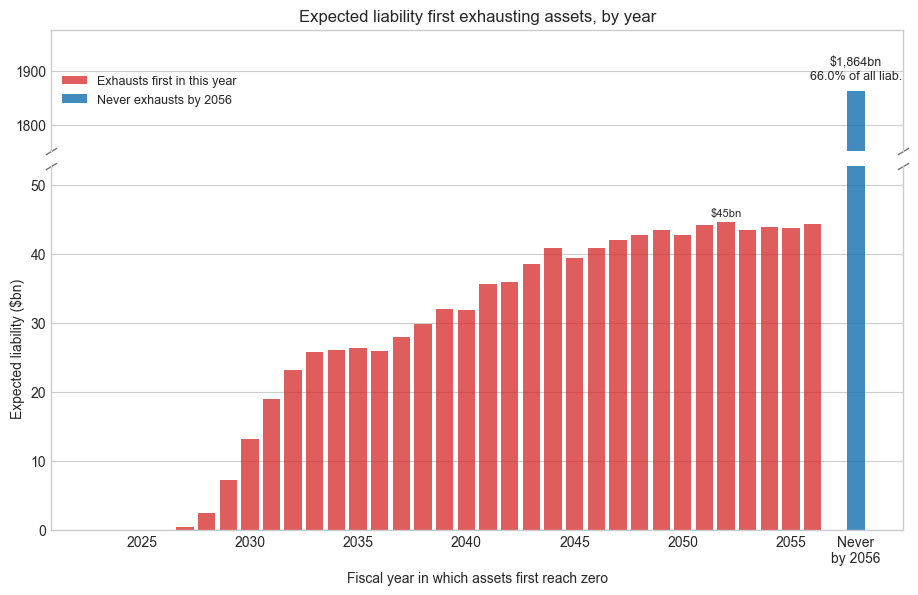

,bin,expected_liability_billion,liability_share,years_in_bin,expected_liability_per_year_billion
0,2023-2032,65.825,0.023,10.0,6.582
1,2033-2042,297.775,0.105,10.0,29.778
2,2043-2052,419.951,0.149,10.0,41.995
3,2053-2056,175.797,0.062,4.0,43.949
4,Never by 2056,1863.942,0.660,NaN,NaN


In [34]:
liability_bins = liability_weighted_exhaustion_bins(results, plan_metrics)
by_year, never_billion, total_billion = liability_weighted_exhaustion_by_year(results, plan_metrics)

# Broken y-axis. The never-exhausting bar is about forty times the tallest yearly
# bar, so on one continuous scale every yearly bar collapses to a couple of
# percent of the plot height and the profile becomes unreadable. The break keeps
# both in the same chart against a labelled scale. For a single continuous axis
# instead, drop ax_top and plot everything on one Axes.
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(11, 6.5),
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.06})

x_years = by_year["year"].to_numpy(dtype="float64")
h_years = by_year["expected_liability_billion"].to_numpy(dtype="float64")
x_never = float(ASSET_LAST_YEAR + 2)          # a gap, so it reads as a separate category

for ax in (ax_top, ax_bot):
    ax.bar(x_years, h_years, width=0.8, color="tab:red", alpha=0.75,
           label="Exhausts first in this year")
    ax.bar([x_never], [never_billion], width=0.8, color="tab:blue", alpha=0.85,
           label=f"Never exhausts by {ASSET_LAST_YEAR}")
    ax.xaxis.grid(False)

ax_top.set_ylim(never_billion * 0.94, never_billion * 1.06)
ax_bot.set_ylim(0, float(h_years.max()) * 1.18)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# Diagonal marks showing the axis is broken
_break = dict(marker=[(-1, -0.6), (1, 0.6)], markersize=8, linestyle="none",
              color="0.45", mec="0.45", mew=1, clip_on=False)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **_break)
ax_bot.plot([0, 1], [1, 1], transform=ax_bot.transAxes, **_break)

ax_top.annotate(f"${never_billion:,.0f}bn\n{never_billion / total_billion:.1%} of all liab.",
                xy=(x_never, never_billion), xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, annotation_clip=False)
_peak = int(np.argmax(h_years))
ax_bot.annotate(f"${h_years[_peak]:,.0f}bn", xy=(x_years[_peak], h_years[_peak]),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8)

ticks = [y for y in x_years if int(y) % 5 == 0]
ax_bot.set_xticks(ticks + [x_never])
ax_bot.set_xticklabels([f"{int(y)}" for y in ticks] + [f"Never\nby {ASSET_LAST_YEAR}"])
ax_bot.set_xlabel("Fiscal year in which assets first reach zero")
ax_bot.set_ylabel("Expected liability ($bn)")
ax_top.set_title("Expected liability first exhausting assets, by year")
ax_top.legend(loc="center left", fontsize=9, frameon=False)
plt.show()

# The binned view is kept for reference, with the per-year column that makes the
# four rows comparable -- the bins are not the same width.
display(liability_bins.round(3))


## Asset Exhaustion By Liability Exposure, Cumulative

The same quantity as the chart above, accumulated instead of taken year by year:
how much liability has run out of assets **by** each fiscal year, rather than how
much runs out **in** it. A plan counted once in the bar above appears in every
bar from that year onward here.

Two things worth knowing about it. It contains no information the previous chart
does not — it is that chart's running total — and it is also the liability-weighted
curve from the exhaustion-CDF figure below, expressed in dollars rather than as a
probability. It is here because a cumulative amount is the more natural way to ask
how much is at stake by a given date.

Unlike the chart above, this one needs no broken axis: the final red bar and the
blue bar are the two parts of the same total, so they are of comparable size and
together account for every dollar of liability in the study.

**Exhaustion is absorbing in these runs** — checked across all 40 plans, no path
ever returns to positive assets after reaching zero (0 of 132,127 exhausting
paths). So "has exhausted by this year" and "is exhausted in this year" are the
same series here, and this chart can be read either way.

In [ ]:
cumulative, never_cum_billion, total_cum_billion = liability_weighted_exhausted_by_year(
    results, plan_metrics)

fig, ax = plt.subplots(figsize=(11, 5.5))

x_years_c = cumulative["year"].to_numpy(dtype="float64")
h_years_c = cumulative["expected_liability_billion"].to_numpy(dtype="float64")
x_never_c = float(ASSET_LAST_YEAR + 2)        # a gap, so it reads as a separate category

ax.bar(x_years_c, h_years_c, width=0.8, color="tab:red", alpha=0.75,
       label=f"Has exhausted by this year")
ax.bar([x_never_c], [never_cum_billion], width=0.8, color="tab:blue", alpha=0.85,
       label=f"Never exhausts by {ASSET_LAST_YEAR}")
ax.xaxis.grid(False)

ax.annotate(f"${never_cum_billion:,.0f}bn\n{never_cum_billion / total_cum_billion:.1%}",
            xy=(x_never_c, never_cum_billion), xytext=(0, 5), textcoords="offset points",
            ha="center", va="bottom", fontsize=9)
ax.annotate(f"${h_years_c[-1]:,.0f}bn\n{h_years_c[-1] / total_cum_billion:.1%}",
            xy=(x_years_c[-1], h_years_c[-1]), xytext=(0, 5), textcoords="offset points",
            ha="center", va="bottom", fontsize=9)

ticks_c = [y for y in x_years_c if int(y) % 5 == 0]
ax.set_xticks(ticks_c + [x_never_c])
ax.set_xticklabels([f"{int(y)}" for y in ticks_c] + [f"Never\nby {ASSET_LAST_YEAR}"])
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Expected liability ($bn)")
ax.set_title("Expected liability that has exhausted assets, cumulative")
ax.set_ylim(0, max(float(h_years_c.max()), never_cum_billion) * 1.20)
ax.legend(loc="upper left", fontsize=9, frameon=False)
plt.show()

print(f"By {ASSET_LAST_YEAR}: ${h_years_c[-1]:,.0f}bn of liability expected to have "
      f"exhausted assets and ${never_cum_billion:,.0f}bn expected not to, "
      f"of ${total_cum_billion:,.0f}bn total.")

## Exhaustion-Year Distribution

The first figure shows the cumulative probability that assets are exhausted by each projection year: the liability-weighted curve across all plans, plus the individual curves for the highest-risk plans. The second figure shows each plan's full exhaustion CDF as small multiples of risk, sorted from highest to lowest 35-year exhaustion probability.

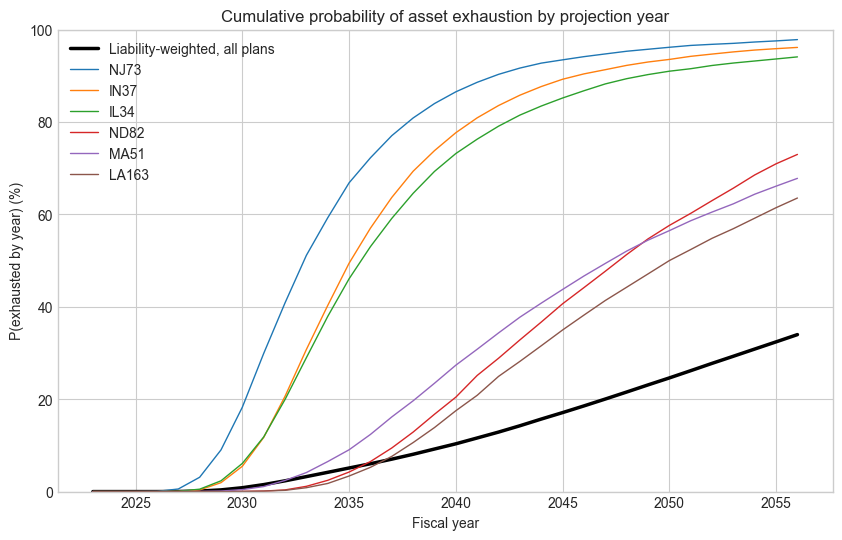

,by_2027,by_2032,by_2037,by_2042,by_2047,by_2052,by_2056
NJ73,0.6,40.8,77.0,90.3,94.7,96.8,97.8
IN37,0.0,20.6,63.7,83.6,91.3,94.7,96.1
IL34,0.1,19.9,59.1,79.1,88.2,92.2,94.1
ND82,0.0,0.4,9.4,28.9,47.7,63.0,73.0
MA51,0.0,2.4,16.2,34.3,49.4,60.5,67.8
LA163,0.0,0.3,7.6,24.9,41.4,54.8,63.5
MO175,0.0,0.1,3.8,15.5,33.7,50.5,59.1
TX108,0.0,0.3,5.8,18.6,33.6,47.4,57.1
MO64,0.0,0.1,4.5,16.7,31.5,45.2,55.6
NM74,0.0,0.1,4.1,15.7,30.5,43.3,51.8


In [6]:
cdf_by_plan, cdf_weighted = exhaustion_cdf(results, plan_metrics, max_year=N_PROJ)

top_risk = exhaustion.nlargest(6, EXH_COL_MAX)["plan"].tolist()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(BASE_YEAR + cdf_weighted.index, cdf_weighted * 100, color="black", linewidth=2.5, label="Liability-weighted, all plans")
for plan in top_risk:
    ax.plot(BASE_YEAR + cdf_by_plan.index, cdf_by_plan[plan] * 100, linewidth=1, label=plan)
ax.set_title("Cumulative probability of asset exhaustion by projection year")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("P(exhausted by year) (%)")
ax.set_ylim(0, 100)
ax.legend()
plt.show()

# Exhaustion CDF table at selected horizons (plan rows sorted by risk)
horizon_cols = [5, 10, 15, 20, 25, 30, MAX_OFFSET]
cdf_table = (cdf_by_plan.loc[horizon_cols].T * 100).round(1)
cdf_table.columns = [f"by_{BASE_YEAR + h}" for h in horizon_cols]
display(cdf_table.sort_values(f"by_{ASSET_LAST_YEAR}", ascending=False))

## Plan-Level Exhaustion Probabilities

Each plan's cumulative probability of exhausting assets by three fiscal years. The bars nest because the measure is cumulative: a plan that has exhausted by 2032 has also exhausted by 2042. The full per-plan frame is available as `exhaustion` for custom queries.

**A severity panel used to sit beside this and has been removed.** It plotted `mean_years_insolvent`, the average number of projection years spent with zero assets — averaged over *every* path, including those where the plan never runs out and which therefore contribute zero. That makes it roughly the exhaustion probability multiplied by the duration, so it largely restated the bars on the left rather than adding a second dimension, and its title ("horizon") described a point in time while the quantity was a count of years. The column is still computed and available in `exhaustion` if wanted.

**Severity now lives in its own section below**, where it is measured *conditionally* — given that a plan does run out, how large the shortfall is and how long it lasts — which separates the size of the problem from how often it happens.


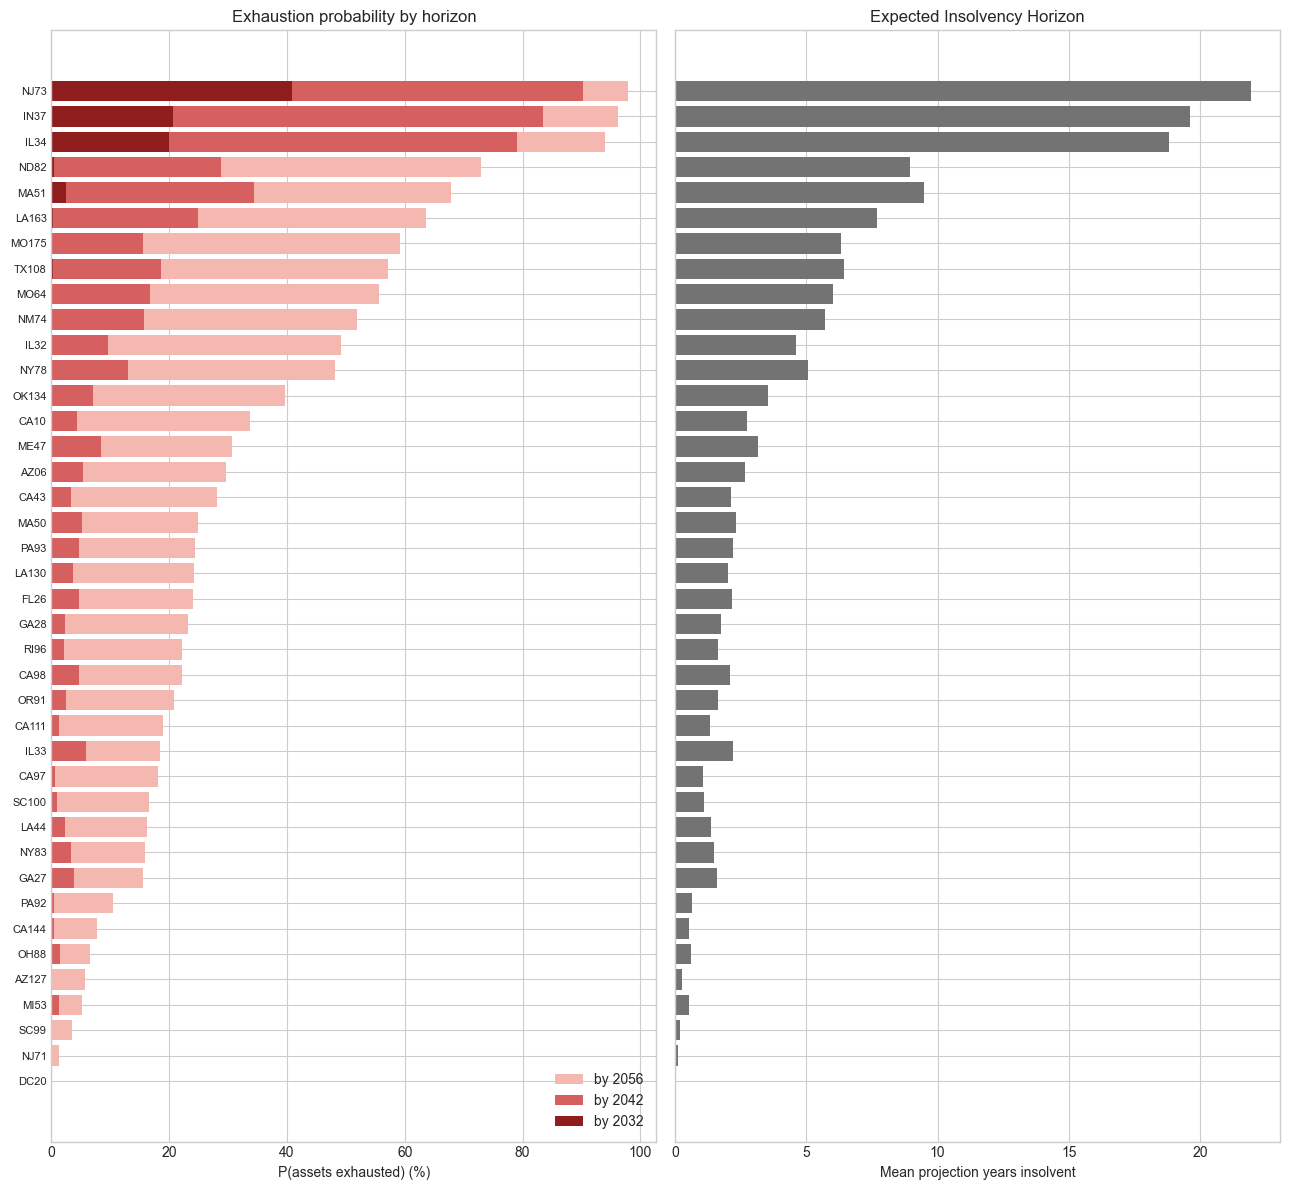

In [7]:
t = exhaustion.sort_values(EXH_COL_MAX, ascending=True).reset_index(drop=True)
y = np.arange(len(t))

fig, ax = plt.subplots(figsize=(8, max(6, len(t) * 0.30)))
ax.barh(y, t[EXH_COL_MAX] * 100, color="#f4b8b0", label=f"by {ASSET_LAST_YEAR}")
ax.barh(y, t[EXH_COLS[20]] * 100, color="#d65f5f", label=f"by {BASE_YEAR + 20}")
ax.barh(y, t[EXH_COLS[10]] * 100, color="#8f1d1d", label=f"by {BASE_YEAR + 10}")
ax.set_yticks(y)
ax.set_yticklabels(t["plan"], fontsize=8)
ax.set_xlabel("P(assets exhausted) (%)")
ax.set_title("Exhaustion probability by horizon")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Probability Below Funding-Ratio Thresholds Over Time

The figure shows the cross-plan average probability that simulated funding ratios fall below selected thresholds in each projection year, over the full usable horizon. The probability of being *at or above* full funding in a year is one minus the `< 1.0` line.

,plan,year,threshold,probability
0,AZ06,2022,0.4,0.0000
1,AZ06,2022,0.6,0.0000
2,AZ06,2022,0.8,1.0000
3,AZ06,2022,1.0,1.0000
4,AZ06,2023,0.4,0.0098


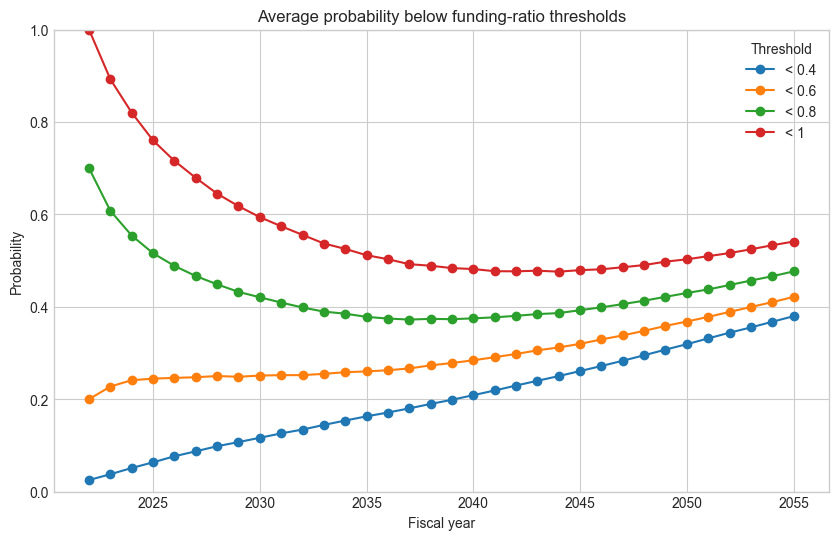

In [9]:
risk_over_time = ra.threshold_risk_over_time(results, thresholds=(0.4, 0.6, 0.8, 1.0), graph_years=N_PROJ)
display(risk_over_time.head())

fig, ax = ra.plot_threshold_risk(results, thresholds=(0.4, 0.6, 0.8, 1.0), graph_years=N_PROJ)
plt.show()

## Funding-Ratio Distribution At Selected Horizons

Each row shows a plan's simulated funding-ratio distribution — thin line 5-95 percentile, thick line 20-80 percentile, tick at the median — at the `GRAPH_YEARS` mark (left) and at the end of the usable projection (right), sorted by median. The x-axis is capped at 3 for readability; upper tails of well-funded plans extend beyond it. The pooled histogram below shows all plan-path funding ratios at the shorter horizon. Full per-plan stats (including `prob_depleted` and threshold probabilities) remain available as `terminal_short` / `terminal_long`.

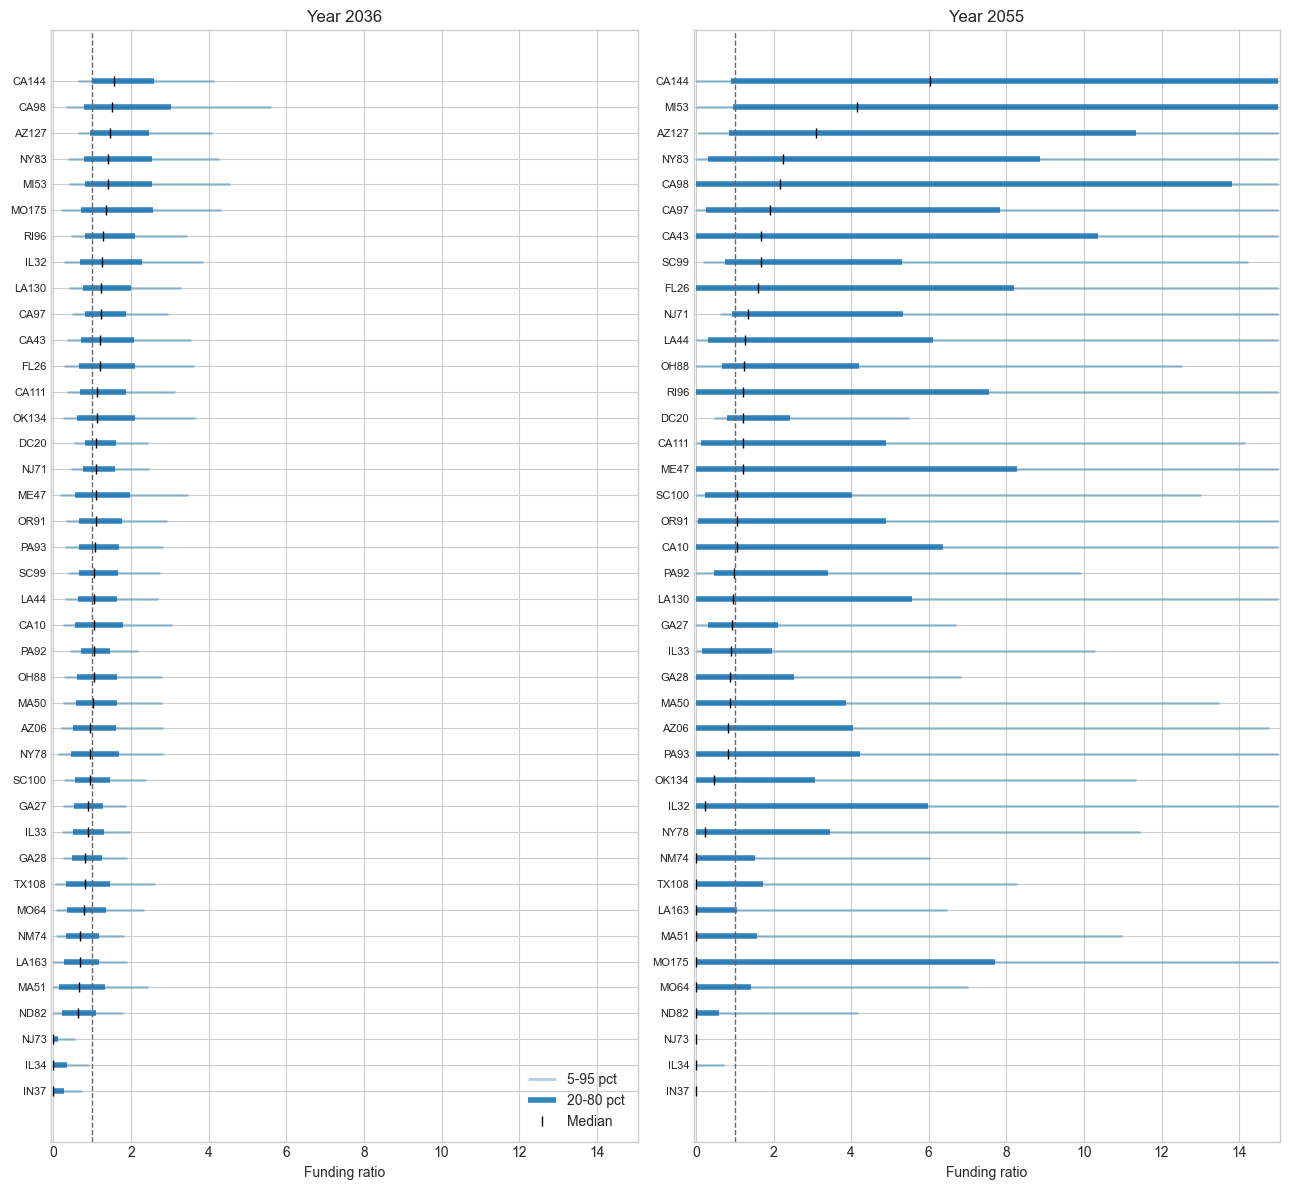

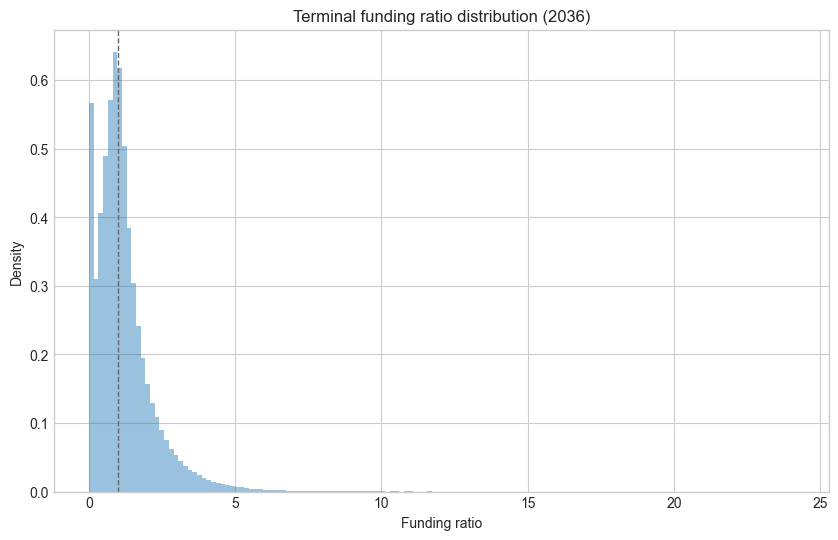

In [ ]:
terminal_short = ra.terminal_risk_table(results, year_offset=GRAPH_YEARS - 1, thresholds=(0.4, 0.6, 0.8, 1.0))
terminal_long = ra.terminal_risk_table(results, year_offset=N_PROJ - 1, thresholds=(0.4, 0.6, 0.8, 1.0))

# WHY IS THE CAP AT 3?
def plot_fr_intervals(table, title, ax, x_cap=3.0):
    t = table.sort_values("median").reset_index(drop=True)
    y = np.arange(len(t))
    ax.hlines(y, t["q05"].clip(upper=x_cap), t["q95"].clip(upper=x_cap),
              color="tab:blue", alpha=0.35, linewidth=2, label="5-95 pct")
    ax.hlines(y, t["q20"].clip(upper=x_cap), t["q80"].clip(upper=x_cap),
              color="tab:blue", alpha=0.9, linewidth=4, label="20-80 pct")
    ax.plot(t["median"].clip(upper=x_cap), y, "k|", markersize=7, label="Median")
    ax.axvline(1.0, color="0.4", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(t["plan"], fontsize=8)
    ax.set_xlim(-0.05, x_cap + 0.05)
    ax.set_xlabel("Funding ratio")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(13, max(6, len(terminal_short) * 0.30)))
plot_fr_intervals(terminal_short, f"Year {int(terminal_short['year'].iloc[0])}", axes[0])
plot_fr_intervals(terminal_long, f"Year {int(terminal_long['year'].iloc[0])}", axes[1])
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = ra.plot_terminal_distribution(results, year_offset=GRAPH_YEARS - 1)
plt.show()

## Distress-Probability Heatmap

Each cell is the probability that a plan's funding ratio is below 0.4 in that projection year — deep distress, near the point where exhaustion becomes hard to avoid. Plans are sorted by overall distress probability. (For a central-tendency view, the module's `ra.plot_plan_heatmap(results, statistic="q50")` is still available.)

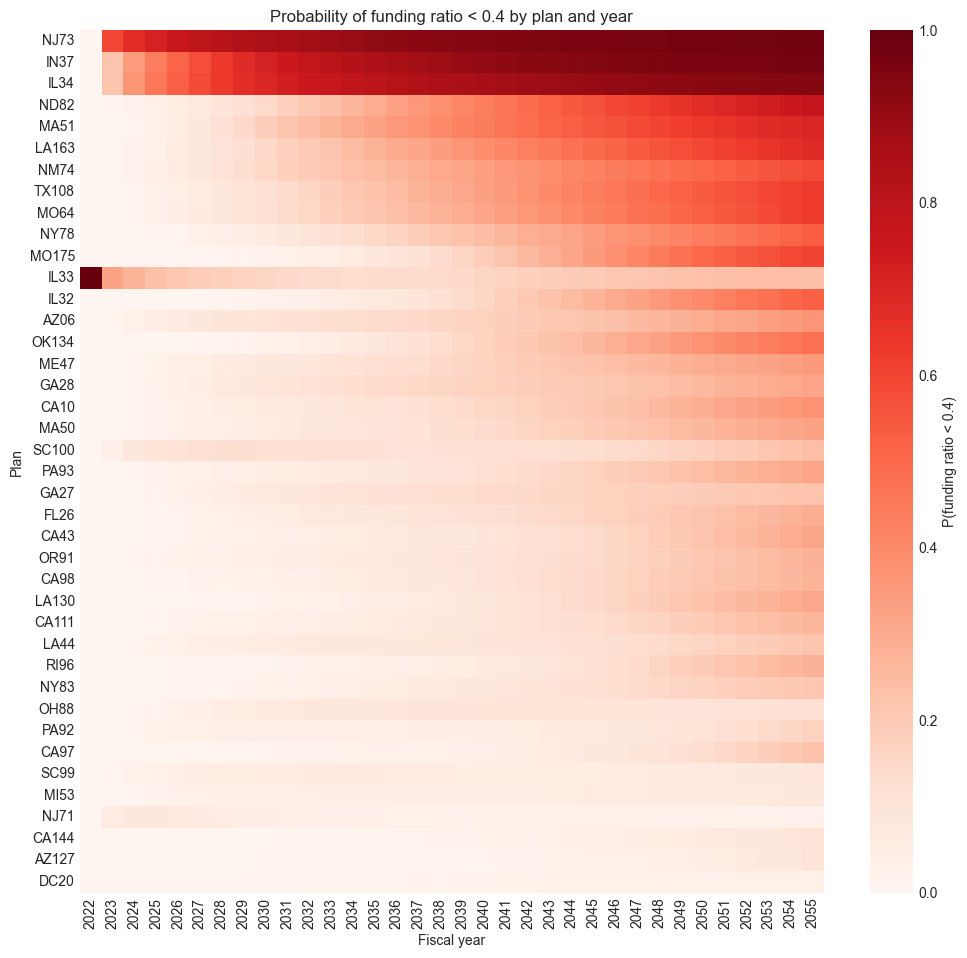

In [11]:
DISTRESS_THRESHOLD = 0.4
risk_full = ra.threshold_risk_over_time(results, thresholds=(DISTRESS_THRESHOLD,), graph_years=N_PROJ)
heat = risk_full.pivot_table(index="plan", columns="year", values="probability")
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, max(6, len(heat) * 0.28)))
sns.heatmap(heat, ax=ax, cmap="Reds", vmin=0, vmax=1,
            cbar_kws={"label": f"P(funding ratio < {DISTRESS_THRESHOLD})"})
ax.set_title(f"Probability of funding ratio < {DISTRESS_THRESHOLD} by plan and year")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Plan")
plt.show()

## Exhaustion Risk By Official Funded Ratio

Cross-sectional relationship between each plan's official funded ratio in the base year and its simulated probability of exhausting assets within 20 years. Bubble size is proportional to GASB liabilities. The fitted line is a simple linear regression used only as a visual summary.

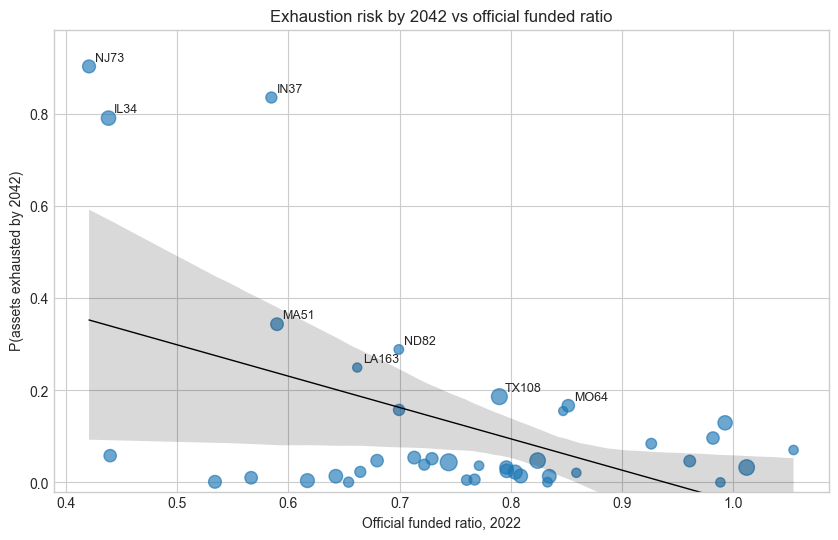

,plan,PlanName,official_funded_ratio,prob_exhaust_by_2032,prob_exhaust_by_2042,prob_exhaust_by_2052,liability_billion,unfunded_liabilities_payroll,contribution_rate
27,NJ73,New Jersey Teachers,0.421,0.408,0.903,0.968,72.609,3.654,0.443
15,IN37,Indiana Teachers,0.585,0.206,0.836,0.947,22.214,2.054,0.393
14,IL34,Illinois Teachers,0.438,0.199,0.791,0.922,143.524,6.921,0.606
20,MA51,Massachusetts Teachers,0.590,0.024,0.343,0.605,60.308,3.211,0.425
25,ND82,North Dakota Teachers,0.699,0.004,0.289,0.630,4.480,1.712,0.248
17,LA163,Baton Rouge City-Parish (LA) ERS,0.662,0.003,0.249,0.548,1.978,4.355,0.472
39,TX108,Texas Teachers,0.790,0.003,0.186,0.474,245.561,0.981,0.170
24,MO64,Missouri Teachers,0.852,0.001,0.166,0.452,55.405,1.599,0.306
28,NM74,New Mexico PERA,0.700,0.001,0.157,0.433,23.924,2.922,0.295
23,MO175,Kansas City (MO) ERS,0.847,0.001,0.155,0.505,1.492,1.381,0.232


In [12]:
risk_scatter = exhaustion.merge(
    plan_metrics[["plan", "PlanName", "assets_liabilities", "liability_billion", "unfunded_liabilities_payroll", "contribution_rate"]],
    on="plan",
    suffixes=("", "_metric"),
)
plot_df = risk_scatter.dropna(subset=["official_funded_ratio", EXH_COLS[20], "liability_billion"])
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 35 + 6 * np.sqrt(plot_df["liability_billion"].clip(lower=0))
ax.scatter(plot_df["official_funded_ratio"], plot_df[EXH_COLS[20]], s=sizes, alpha=0.65)
sns.regplot(data=plot_df, x="official_funded_ratio", y=EXH_COLS[20], scatter=False, ax=ax, color="black", line_kws={"linewidth": 1})
for _, row in plot_df.sort_values(EXH_COLS[20], ascending=False).head(8).iterrows():
    ax.annotate(row["plan"], (row["official_funded_ratio"], row[EXH_COLS[20]]), fontsize=9, xytext=(4, 4), textcoords="offset points")
ax.set_title(f"Exhaustion risk by {BASE_YEAR + 20} vs official funded ratio")
ax.set_xlabel(f"Official funded ratio, {BASE_YEAR}")
ax.set_ylabel(f"P(assets exhausted by {BASE_YEAR + 20})")
ax.set_ylim(-0.02, min(1.02, max(0.1, plot_df[EXH_COLS[20]].max() + 0.08)))
plt.show()

display(plot_df[["plan", "PlanName", "official_funded_ratio", EXH_COLS[10], EXH_COLS[20], EXH_COLS[30], "liability_billion", "unfunded_liabilities_payroll", "contribution_rate"]].sort_values(EXH_COLS[20], ascending=False).round(3))

## Exhaustion Risk By Contribution Rate

Relationship between each plan's current contribution rate (total pension contributions divided by payroll) and its simulated 20-year exhaustion probability. Descriptive, not causal: high contribution rates may reflect plan stress rather than preventing it.

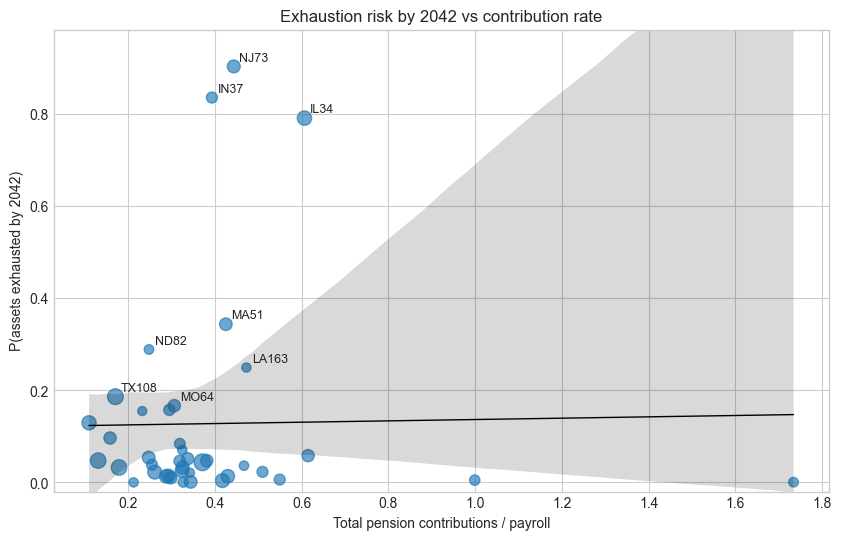

,plan,PlanName,contribution_rate,prob_exhaust_by_2032,prob_exhaust_by_2042,prob_exhaust_by_2052,liability_billion,official_funded_ratio,unfunded_liabilities_payroll
27,NJ73,New Jersey Teachers,0.443,0.408,0.903,0.968,72.609,0.421,3.654
15,IN37,Indiana Teachers,0.393,0.206,0.836,0.947,22.214,0.585,2.054
14,IL34,Illinois Teachers,0.606,0.199,0.791,0.922,143.524,0.438,6.921
20,MA51,Massachusetts Teachers,0.425,0.024,0.343,0.605,60.308,0.590,3.211
25,ND82,North Dakota Teachers,0.248,0.004,0.289,0.630,4.480,0.699,1.712
17,LA163,Baton Rouge City-Parish (LA) ERS,0.472,0.003,0.249,0.548,1.978,0.662,4.355
39,TX108,Texas Teachers,0.170,0.003,0.186,0.474,245.561,0.790,0.981
24,MO64,Missouri Teachers,0.306,0.001,0.166,0.452,55.405,0.852,1.599
28,NM74,New Mexico PERA,0.295,0.001,0.157,0.433,23.924,0.700,2.922
23,MO175,Kansas City (MO) ERS,0.232,0.001,0.155,0.505,1.492,0.847,1.381


In [13]:
contribution_scatter = exhaustion.merge(
    plan_metrics[["plan", "PlanName", "official_funded_ratio", "liability_billion", "unfunded_liabilities_payroll", "contribution_rate"]],
    on="plan",
    suffixes=("", "_metric"),
)
plot_df = contribution_scatter.dropna(subset=["contribution_rate", EXH_COLS[20], "liability_billion"])

fig, ax = plt.subplots(figsize=(10, 6))
sizes = 35 + 6 * np.sqrt(plot_df["liability_billion"].clip(lower=0))
ax.scatter(plot_df["contribution_rate"], plot_df[EXH_COLS[20]], s=sizes, alpha=0.65)
sns.regplot(data=plot_df, x="contribution_rate", y=EXH_COLS[20], scatter=False, ax=ax, color="black", line_kws={"linewidth": 1})
for _, row in plot_df.sort_values(EXH_COLS[20], ascending=False).head(8).iterrows():
    ax.annotate(row["plan"], (row["contribution_rate"], row[EXH_COLS[20]]), fontsize=9, xytext=(4, 4), textcoords="offset points")
ax.set_title(f"Exhaustion risk by {BASE_YEAR + 20} vs contribution rate")
ax.set_xlabel("Total pension contributions / payroll")
ax.set_ylabel(f"P(assets exhausted by {BASE_YEAR + 20})")
ax.set_ylim(-0.02, min(1.02, max(0.1, plot_df[EXH_COLS[20]].max() + 0.08)))
plt.show()

display(
    plot_df[["plan", "PlanName", "contribution_rate", EXH_COLS[10], EXH_COLS[20], EXH_COLS[30], "liability_billion", "official_funded_ratio", "unfunded_liabilities_payroll"]]
    .sort_values(EXH_COLS[20], ascending=False)
    .round(3)
)

## Conditional Severity: How Big Is The Hole, Given That It Opens

Exhaustion probability says how often a plan runs out of assets. It says nothing
about how much money is involved when it does. This section measures the size.

Two quantities, both conditional on a path in which the plan does run out:

- **Liability outstanding at exhaustion** — the accrued liability still on the
  books in the year assets first reach zero. Assets are floored at zero in the
  simulation, so in that year the entire remaining liability is unfunded.
- **Pay-as-you-go shortfall** — once assets are gone, benefits still have to be
  paid out of current money. For every year in which a plan holds zero assets,
  this is the amount by which benefit payments exceed contributions coming in.
  It is reported both undiscounted and discounted back to the base year at the
  plan's own discount rate.

Note what varies and what does not. In these runs the liability and cash-flow
paths are deterministic — one column, repeated across simulations — so all the
variation across paths comes from asset returns. The severity measures are
therefore driven by *when* a plan exhausts, not by a separate random liability.

The final figure is the one worth dwelling on: probability against conditional
severity. A plan that fails rarely but expensively and a plan that fails often
but cheaply are very different objects, and a single exhaustion probability
cannot tell them apart.

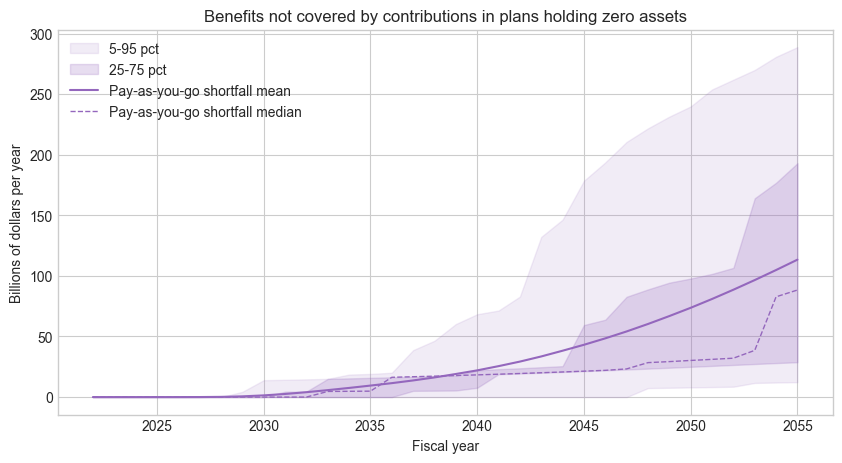

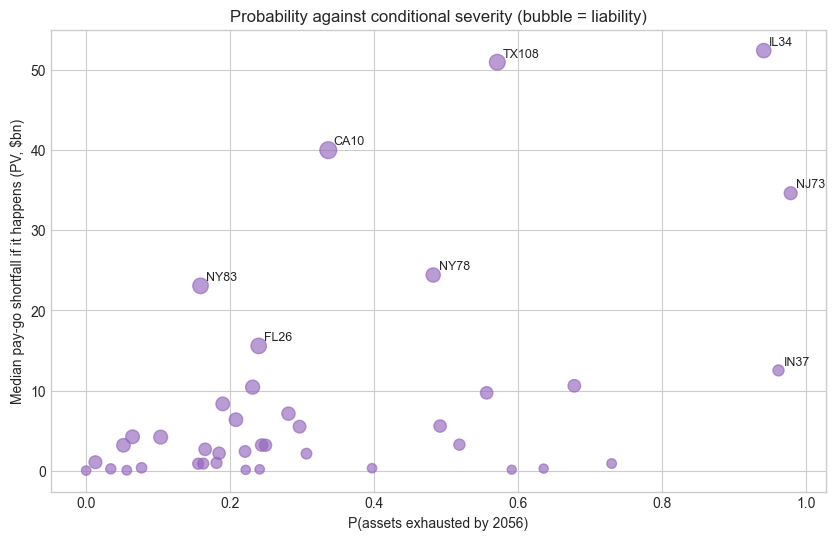

,plan,liability_billion,prob_exhaust,median_liability_at_exhaustion_billion,median_paygo_pv_billion,p90_paygo_pv_billion,median_paygo_pv_pct_liability,median_years_depleted_if_exhausts
14,IL34,143.524,0.941,140.997,52.369,72.815,36.488,20.0
39,TX108,245.561,0.571,352.560,50.918,106.481,20.735,10.0
2,CA10,346.089,0.336,441.107,39.962,104.644,11.547,6.0
27,NJ73,72.609,0.978,75.828,34.598,41.903,47.649,23.0
29,NY78,135.531,0.482,172.273,24.403,52.205,18.005,9.0
30,NY83,223.875,0.159,219.724,23.052,58.170,10.297,8.0
9,FL26,217.434,0.240,166.842,15.567,43.332,7.160,7.0
15,IN37,22.214,0.961,29.080,12.514,16.232,56.333,21.0
20,MA51,60.308,0.678,41.155,10.599,18.907,17.574,14.0
11,GA28,120.491,0.232,199.938,10.426,24.382,8.653,6.0


In [14]:
# Liability and cash-flow matrices are recycled from a single deterministic
# column, so column 0 represents every path. Verified rather than assumed.
def _deterministic_column(result, name):
    arr = result.matrix(name).to_numpy(dtype="float64")
    if not np.allclose(arr, arr[:, [0]], equal_nan=True):
        raise ValueError(f"{result.plan}: {name} varies across simulations; "
                         "the severity section assumes it does not.")
    return arr[:, 0]


def severity_paths(result):
    """Per-path pay-go shortfall, plus the liability outstanding at exhaustion."""
    assets = result.matrix("Assets").to_numpy(dtype="float64")
    aal = _deterministic_column(result, "AAL")
    outflow = _deterministic_column(result, "cash_outflows")
    inflow = _deterministic_column(result, "cash_inflows")
    rate = float(result.scalars.get("discountrate", np.nan))

    # Liability-side years only: AAL and the flows stop one year before assets.
    t = np.arange(N_PROJ)
    depleted = assets[:N_PROJ, :] <= 0
    annual_gap = np.maximum(outflow[:N_PROJ] - inflow[:N_PROJ], 0.0)[:, None] * depleted
    discount = (1.0 + rate) ** (-t.astype(float))
    return {
        "annual_gap": annual_gap,                              # (N_PROJ, n_sim)
        "total_gap": annual_gap.sum(axis=0),
        "total_gap_pv": (annual_gap * discount[:, None]).sum(axis=0),
        "aal": aal,
        "depleted": depleted,
    }


sev = {plan: severity_paths(result) for plan, result in sorted(results.items())}

rows = []
for plan, result in sorted(results.items()):
    s = sev[plan]
    offsets = first_exhaustion_offsets(result)
    # Liability outstanding at exhaustion needs an AAL value, so it is defined
    # only for exhaustions inside the liability horizon.
    within = np.isfinite(offsets) & (offsets <= N_PROJ - 1)
    idx = offsets[within].astype(int)
    liab_at_exh = s["aal"][idx] / 1e9 if idx.size else np.array([])
    exhausts = np.isfinite(offsets)
    gap_pv = s["total_gap_pv"][exhausts] / 1e9
    liability = plan_metrics.set_index("plan").loc[plan, "liability_billion"]
    rows.append({
        "plan": plan,
        "liability_billion": liability,
        "prob_exhaust": float(exhausts.mean()),
        "median_liability_at_exhaustion_billion": float(np.median(liab_at_exh)) if liab_at_exh.size else np.nan,
        "median_paygo_pv_billion": float(np.median(gap_pv)) if gap_pv.size else np.nan,
        "p90_paygo_pv_billion": float(np.quantile(gap_pv, 0.90)) if gap_pv.size else np.nan,
        "median_paygo_pv_pct_liability": float(np.median(gap_pv) / liability * 100) if gap_pv.size and liability > 0 else np.nan,
        "median_years_depleted_if_exhausts": float(np.median(s["depleted"].sum(axis=0)[exhausts])) if exhausts.any() else np.nan,
    })
severity = pd.DataFrame(rows)

# --- aggregate pay-go requirement across all plans, path by path -------------
agg_gap = np.zeros_like(sev[next(iter(sev))]["annual_gap"])
for s in sev.values():
    agg_gap = agg_gap + s["annual_gap"]
gap_years = np.arange(BASE_YEAR, BASE_YEAR + N_PROJ)
gap_fan = fan_table(gap_years, agg_gap / 1e9)

fig, ax = plt.subplots(figsize=(10, 5))
plot_fan(ax, gap_fan, "Pay-as-you-go shortfall", color="tab:purple")
ax.set_title("Benefits not covered by contributions in plans holding zero assets")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Billions of dollars per year")
ax.legend()
plt.show()

# --- probability against conditional severity -------------------------------
p = severity.dropna(subset=["median_paygo_pv_billion"])
p = p.loc[p["prob_exhaust"] > 0]
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 35 + 6 * np.sqrt(p["liability_billion"].clip(lower=0))
ax.scatter(p["prob_exhaust"], p["median_paygo_pv_billion"], s=sizes, alpha=0.65, color="tab:purple")
for _, row in p.nlargest(8, "median_paygo_pv_billion").iterrows():
    ax.annotate(row["plan"], (row["prob_exhaust"], row["median_paygo_pv_billion"]),
                fontsize=9, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("P(assets exhausted by %d)" % ASSET_LAST_YEAR)
ax.set_ylabel("Median pay-go shortfall if it happens (PV, $bn)")
ax.set_title("Probability against conditional severity (bubble = liability)")
plt.show()

display(severity.sort_values("median_paygo_pv_billion", ascending=False).round(3))

---
# Part 2: Cross-Plan And Aggregate Dynamics

## Aggregate Funded Ratio And Unfunded Liability

Both figures aggregate simulated dollar balances across plans **within each Monte Carlo path** and then summarize across paths. Because all plans share common market shocks, these fans are genuine aggregate risk distributions: a bad path is bad for every plan at once. The first figure shows the aggregate funded ratio; the second the aggregate unfunded liability (AAL − assets) in dollars, which becomes negative when aggregate assets exceed aggregate liabilities. Years with nonpositive aggregate AAL (placeholder final year) are excluded.

## Joint Failure: What Happens Across Plans Within One Market Path

Everything above measures one plan at a time. This section measures how many
plans fail **together**, which is a different question and is only answerable
because every plan in the run is simulated against the same market history:
simulation column *n* is one shared sequence of market outcomes, so a path that
is bad for one plan is bad for all of them at once.

The comparison at the end is the point of the section. Each plan's individual
exhaustion probability is a fact about that plan. Multiplying those individual
probabilities together — treating plans as if they failed independently — gives
a very different answer from what the simulation actually produces, because in
reality the plans share one economy. The gap between the two is a measure of
how much a plan-by-plan reading understates the risk of many plans failing at
the same time.

The independence benchmark is computed exactly, not simulated: it is the
Poisson-binomial distribution implied by the 40 individual probabilities.

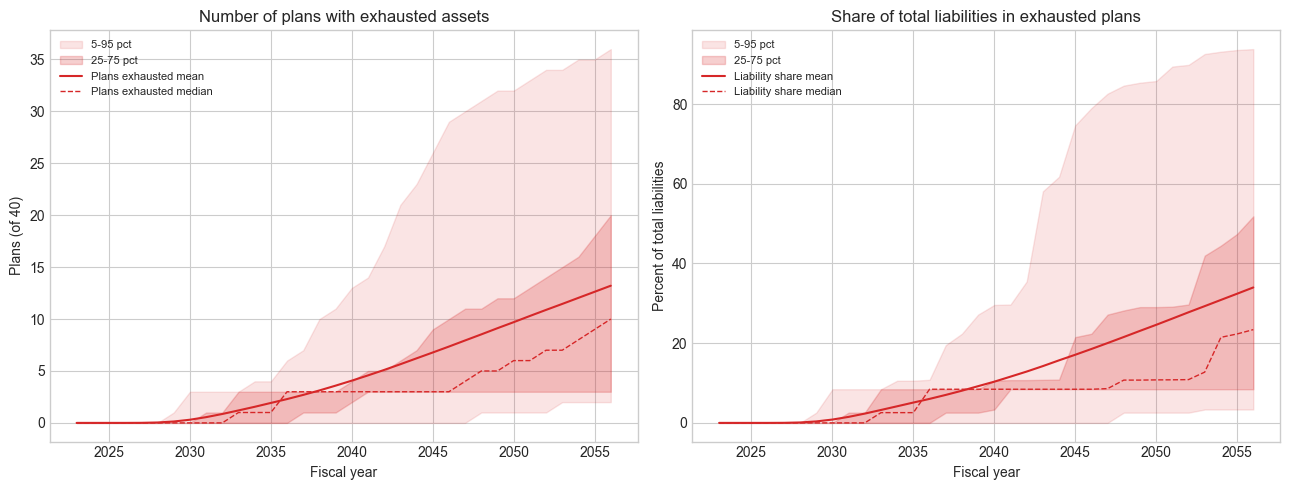

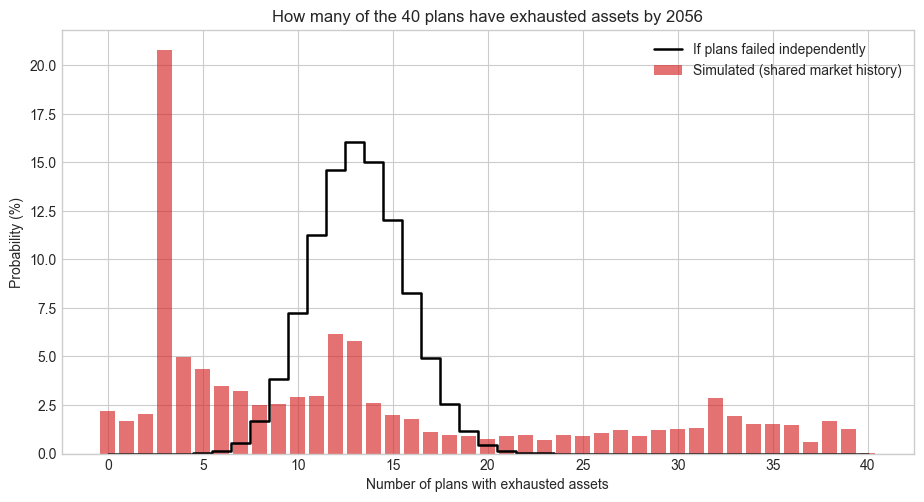

Mean number of plans exhausted by 2056: simulated 13.21, independent 13.21 (these agree by construction -- only the SPREAD differs)


,at_least_n_plans,simulated,if_independent,ratio
5,5,0.6834,1.0000,6.834000e-01
10,10,0.5218,0.9376,5.565000e-01
15,15,0.3177,0.2963,1.072200e+00
20,20,0.2501,0.0067,3.754700e+01
25,25,0.2076,0.0000,3.294331e+04
30,30,0.1548,0.0000,9.112174e+08


,group,simulated_joint,product_of_marginals,ratio
0,CA10 + TX108 + NY83,0.1592,0.0306,5.2036


In [15]:
def exhaustion_indicators(results, max_offset):
    """(n_plans, max_offset, n_sim) boolean: has this plan exhausted BY this year?"""
    plans = sorted(results)
    n_sim = min(r.n_simulations for r in results.values())
    out = np.zeros((len(plans), max_offset, n_sim), dtype=bool)
    for i, plan in enumerate(plans):
        assets = results[plan].matrix("Assets").to_numpy(dtype="float64")
        out[i] = np.maximum.accumulate(assets[1:max_offset + 1, :n_sim] <= 0, axis=0)
    return plans, out


joint_plans, exhausted_by = exhaustion_indicators(results, MAX_OFFSET)
n_failed = exhausted_by.sum(axis=0)                      # (MAX_OFFSET, n_sim)
joint_years = np.arange(BASE_YEAR + 1, BASE_YEAR + MAX_OFFSET + 1)

liab = plan_metrics.set_index("plan").reindex(joint_plans)["liability_billion"].to_numpy(dtype="float64")
liab = np.where(np.isfinite(liab), liab, 0.0)
share_failed = (exhausted_by * liab[:, None, None]).sum(axis=0) / liab.sum()

# --- how many plans fail together, over time --------------------------------
count_fan = fan_table(joint_years, n_failed.astype(float))
share_fan = fan_table(joint_years, share_failed * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_fan(axes[0], count_fan, "Plans exhausted", color="tab:red")
axes[0].set_title("Number of plans with exhausted assets")
axes[0].set_ylabel("Plans (of %d)" % len(joint_plans))
plot_fan(axes[1], share_fan, "Liability share", color="tab:red")
axes[1].set_title("Share of total liabilities in exhausted plans")
axes[1].set_ylabel("Percent of total liabilities")
for ax in axes:
    ax.set_xlabel("Fiscal year")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- simulated joint distribution vs an independence benchmark --------------
final_counts = n_failed[-1, :]
observed = np.bincount(final_counts, minlength=len(joint_plans) + 1) / final_counts.size

marginals = exhausted_by[:, -1, :].mean(axis=1)
independent = np.zeros(len(marginals) + 1)
independent[0] = 1.0
for prob in marginals:                       # exact Poisson-binomial convolution
    shifted = np.zeros_like(independent)
    shifted[0] = independent[0] * (1 - prob)
    shifted[1:] = independent[1:] * (1 - prob) + independent[:-1] * prob
    independent = shifted

k = np.arange(len(observed))
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(k, observed * 100, color="tab:red", alpha=0.65, label="Simulated (shared market history)")
ax.step(k, independent * 100, where="mid", color="black", linewidth=1.8,
        label="If plans failed independently")
ax.set_title(f"How many of the {len(joint_plans)} plans have exhausted assets by {ASSET_LAST_YEAR}")
ax.set_xlabel("Number of plans with exhausted assets")
ax.set_ylabel("Probability (%)")
ax.legend()
plt.show()

tail = pd.DataFrame({
    "at_least_n_plans": k,
    "simulated": observed[::-1].cumsum()[::-1],
    "if_independent": independent[::-1].cumsum()[::-1],
})
tail["ratio"] = tail["simulated"] / tail["if_independent"].replace(0, np.nan)
print(f"Mean number of plans exhausted by {ASSET_LAST_YEAR}: "
      f"simulated {float((observed * k).sum()):.2f}, independent {float((independent * k).sum()):.2f} "
      "(these agree by construction -- only the SPREAD differs)")
display(tail.loc[tail["at_least_n_plans"].isin([5, 10, 15, 20, 25, 30])].round(4))

# --- do the largest plans fail together? ------------------------------------
big = plan_metrics.nlargest(3, "liability_billion")["plan"].tolist()
rows = []
idx = [joint_plans.index(b) for b in big]
together = exhausted_by[idx, -1, :].all(axis=0).mean()
product = float(np.prod([marginals[i] for i in idx]))
rows.append({"group": " + ".join(big), "simulated_joint": together,
             "product_of_marginals": product,
             "ratio": together / product if product > 0 else np.nan})
display(pd.DataFrame(rows).round(4))

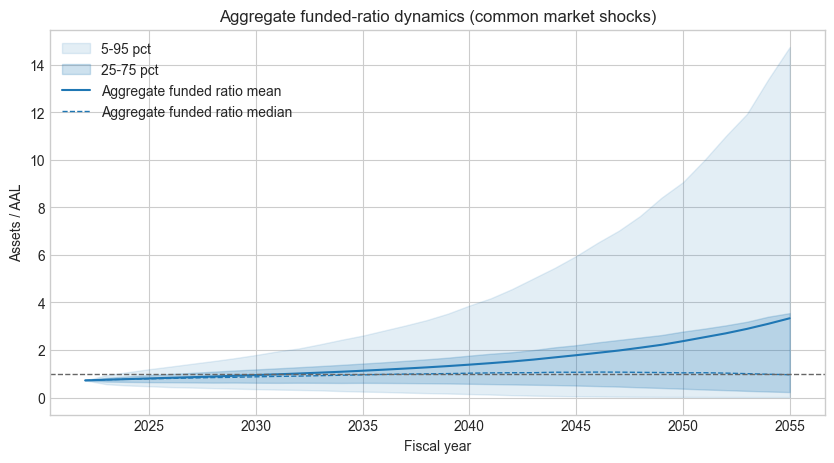

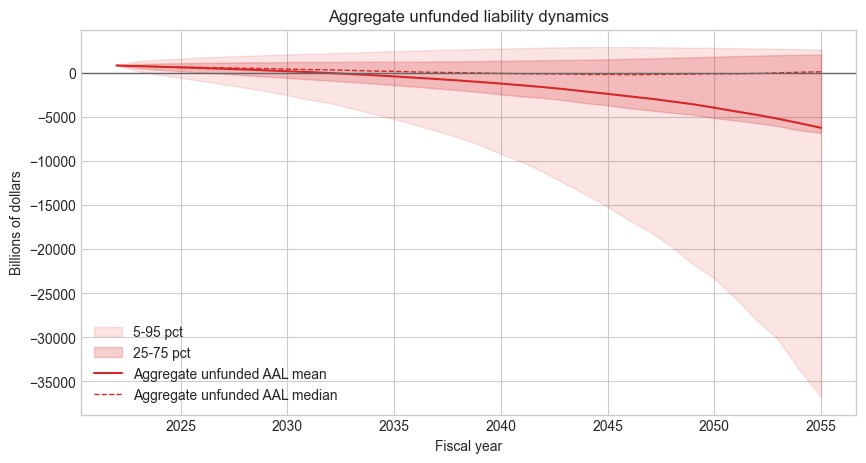

,year,mean,q05,q25,q50,q75,q95
0,2022,0.720,0.720,0.720,0.720,0.720,0.720
1,2023,0.749,0.560,0.671,0.750,0.827,0.937
2,2024,0.775,0.507,0.656,0.770,0.888,1.067
3,2025,0.803,0.475,0.646,0.788,0.942,1.191
4,2026,0.829,0.439,0.641,0.805,0.990,1.302
5,2027,0.856,0.419,0.633,0.822,1.035,1.419
6,2028,0.884,0.394,0.626,0.840,1.087,1.532
7,2029,0.916,0.373,0.629,0.851,1.137,1.654
8,2030,0.946,0.353,0.621,0.871,1.182,1.789
9,2031,0.976,0.334,0.617,0.889,1.227,1.940


In [16]:
ratio_paths = np.divide(agg_assets, agg_aal, out=np.full_like(agg_assets, np.nan), where=agg_aal > 0)
ratio_fan = fan_table(agg_years, ratio_paths)
unfunded_fan = fan_table(agg_years, (agg_aal - agg_assets) / 1_000_000_000)

fig, ax = plt.subplots(figsize=(10, 5))
plot_fan(ax, ratio_fan, "Aggregate funded ratio")
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title("Aggregate funded-ratio dynamics (common market shocks)")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Assets / AAL")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_fan(ax, unfunded_fan, "Aggregate unfunded AAL", color="tab:red")
ax.axhline(0.0, color="0.4", linewidth=1)
ax.set_title("Aggregate unfunded liability dynamics")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Billions of dollars")
ax.legend()
plt.show()

display(ratio_fan.head(10).round(3))

## Average Funding-Ratio Forecast

The black line is the historical equal-weighted average of official funded ratios across the plans in the run. The fan is the simulated continuation: the **equal-weighted average funding ratio across plans, computed within each Monte Carlo path** and then summarized across paths. Per-path cross-plan averaging is valid because all plans share common market shocks. This equal-plan view describes the typical plan and complements the dollar-aggregate fan above, which is dominated by the largest plans.

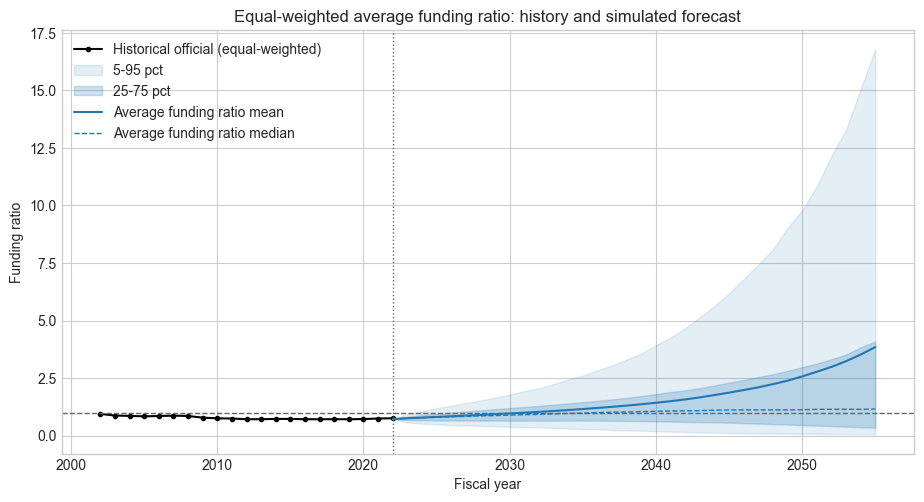

,year,mean,q05,q25,q50,q75,q95
0,2022,0.716,0.716,0.716,0.716,0.716,0.716
1,2023,0.750,0.567,0.674,0.751,0.825,0.932
2,2024,0.779,0.518,0.664,0.774,0.889,1.062
3,2025,0.810,0.491,0.658,0.796,0.944,1.188
4,2026,0.838,0.456,0.656,0.815,0.994,1.299
5,2027,0.867,0.440,0.651,0.834,1.041,1.412
6,2028,0.896,0.416,0.646,0.853,1.095,1.527
7,2029,0.930,0.399,0.652,0.868,1.148,1.648
8,2030,0.961,0.380,0.646,0.888,1.194,1.785
9,2031,0.994,0.363,0.644,0.906,1.240,1.933


In [17]:
# Equal-weighted average funding ratio per path (cross-plan average, valid under common shocks)
n_sims_common = min(r.n_simulations for r in results.values())
fr_stack = np.stack([
    r.funding_ratio().iloc[:N_PROJ, :n_sims_common].to_numpy(dtype="float64")
    for r in results.values()
], axis=0)
avg_fr_paths = np.nanmean(fr_stack, axis=0)
fr_years = np.asarray(next(iter(results.values())).years(N_PROJ))
avg_fr_fan = fan_table(fr_years, avg_fr_paths)

hist = historical_official_funding(ppd, plan_metrics["ppid"].dropna().astype(int).tolist())
hist = hist.loc[hist["fy"].between(2002, BASE_YEAR)]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(hist["fy"], hist["equal_weighted"], color="black", marker="o", markersize=3,
        label="Historical official (equal-weighted)")
plot_fan(ax, avg_fr_fan, "Average funding ratio")
ax.axvline(BASE_YEAR, color="0.4", linestyle=":", linewidth=1)
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title("Equal-weighted average funding ratio: history and simulated forecast")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Funding ratio")
ax.legend()
plt.show()

display(avg_fr_fan.head(10).round(3))

## GDP-Normalized Aggregate Burden

This section normalizes the aggregate balance sheet by nominal GDP. Observed nominal GDP from the official FRED API is used only through the model base year; afterwards GDP grows at a model-consistent nominal rate (average model inflation compounded with the 1 percent population-growth assumption). This is a deterministic scaling denominator, not a macro forecast, so all dispersion in the fan comes from the simulated numerator.

The section requires `FRED_API_KEY` (notebook variable or environment variable); without it, it prints a skip message and the rest of the notebook still runs.

,item,value
0,Base GDP year,2022.000000
1,"Base nominal GDP, billions",26054.614250
2,Average model inflation,0.024933
3,Projected nominal GDP growth,0.035182


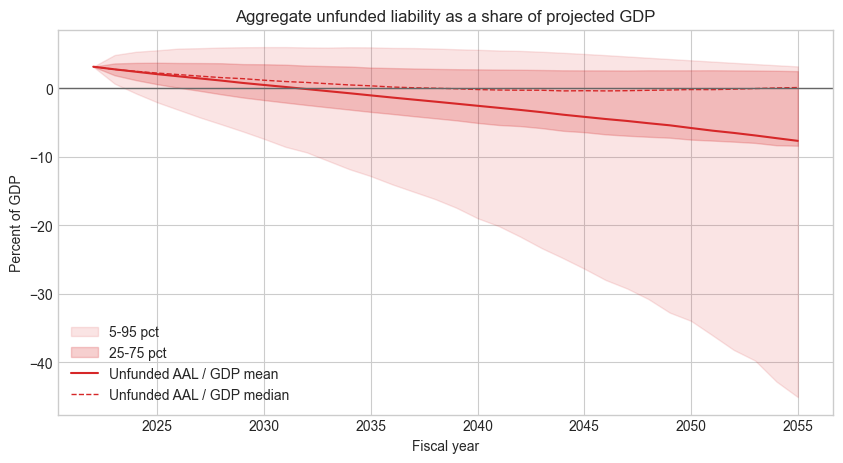

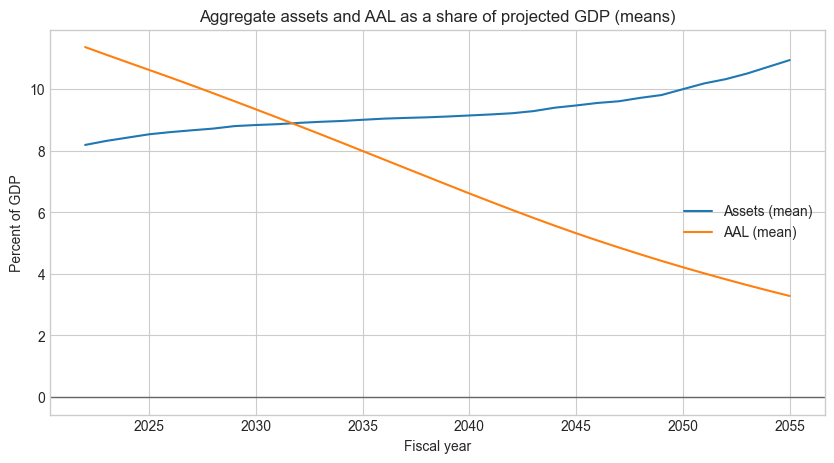

,year,mean,q05,q25,q50,q75,q95
29,2051,-6.166,-36.059,-7.620,-0.174,2.660,3.924
30,2052,-6.496,-38.201,-7.775,-0.104,2.636,3.742
31,2053,-6.865,-39.751,-7.956,-0.016,2.621,3.564
32,2054,-7.264,-42.826,-8.299,0.076,2.583,3.389
33,2055,-7.657,-45.088,-8.368,0.133,2.530,3.220


In [18]:
gdp_series = try_fetch_fred("GDP")

if gdp_series is None:
    print("GDP normalization skipped (no FRED data). Set FRED_API_KEY and rerun this cell.")
else:
    gdp_series["year"] = gdp_series["date"].dt.year
    gdp_annual = gdp_series.groupby("year", as_index=False)["GDP"].mean()
    gdp_observed = gdp_annual.loc[gdp_annual["year"] <= BASE_YEAR]
    base_row = gdp_observed.loc[gdp_observed["year"] == BASE_YEAR]
    if base_row.empty:
        base_row = gdp_observed.tail(1)
    base_gdp_billion = float(base_row["GDP"].iloc[-1])
    base_gdp_year = int(base_row["year"].iloc[-1])

    model_inflation = float(np.nanmean([float(r.scalars.get("Inflation", np.nan)) for r in results.values()]))
    model_nominal_gdp_growth = (1 + model_inflation) * (1 + MODEL_POPULATION_GROWTH) - 1

    gdp_path = base_gdp_billion * (1 + model_nominal_gdp_growth) ** (agg_years.astype(float) - base_gdp_year)

    display(pd.DataFrame([
        {"item": "Base GDP year", "value": base_gdp_year},
        {"item": "Base nominal GDP, billions", "value": base_gdp_billion},
        {"item": "Average model inflation", "value": model_inflation},
        {"item": "Projected nominal GDP growth", "value": model_nominal_gdp_growth},
    ]))

    unfunded_pct_paths = 100 * (agg_aal - agg_assets) / 1_000_000_000 / gdp_path[:, None]
    unfunded_pct_fan = fan_table(agg_years, unfunded_pct_paths)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_fan(ax, unfunded_pct_fan, "Unfunded AAL / GDP", color="tab:red")
    ax.axhline(0.0, color="0.4", linewidth=1)
    ax.set_title("Aggregate unfunded liability as a share of projected GDP")
    ax.set_xlabel("Fiscal year")
    ax.set_ylabel("Percent of GDP")
    ax.legend()
    plt.show()

    assets_pct_mean = 100 * np.nanmean(agg_assets, axis=1) / 1_000_000_000 / gdp_path
    aal_pct_mean = 100 * np.nanmean(agg_aal, axis=1) / 1_000_000_000 / gdp_path
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(agg_years, assets_pct_mean, label="Assets (mean)")
    ax.plot(agg_years, aal_pct_mean, label="AAL (mean)")
    ax.axhline(0, color="0.4", linewidth=1)
    ax.set_title("Aggregate assets and AAL as a share of projected GDP (means)")
    ax.set_xlabel("Fiscal year")
    ax.set_ylabel("Percent of GDP")
    ax.legend()
    plt.show()

    display(unfunded_pct_fan.tail(5).round(3))

---
# Part 3: Per-Plan Detail

## Single-Plan Forecast And Cash Flows

Select one plan: historical official funded ratios (black) followed by the simulated funding-ratio fan over the full usable projection, then mean projected cash inflows and outflows. Change `PLAN` to inspect a different plan.

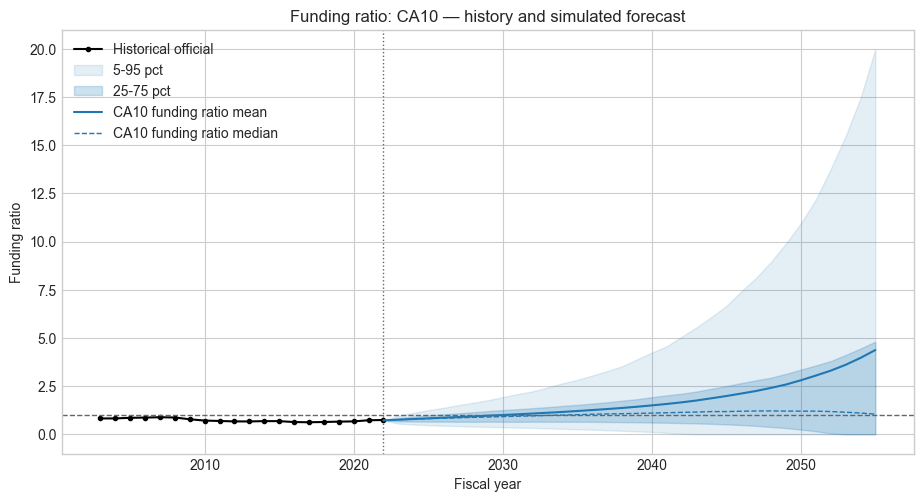

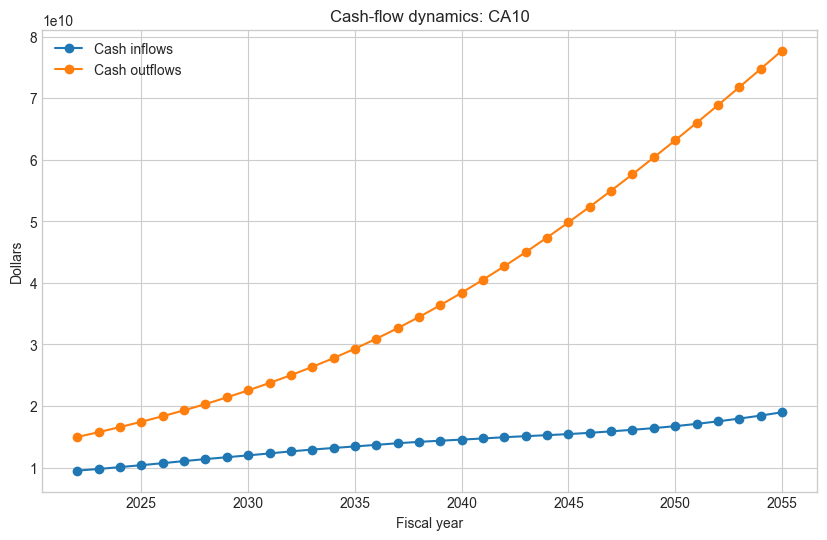

,year,mean,q05,q25,q50,q75,q95
0,2022,0.725,0.725,0.725,0.725,0.725,0.725
1,2023,0.760,0.557,0.676,0.761,0.843,0.962
2,2024,0.795,0.506,0.665,0.787,0.916,1.111
3,2025,0.831,0.478,0.659,0.813,0.981,1.252
4,2026,0.864,0.444,0.658,0.836,1.036,1.376
5,2027,0.896,0.425,0.654,0.859,1.090,1.512
6,2028,0.930,0.403,0.651,0.881,1.147,1.639
7,2029,0.969,0.385,0.658,0.898,1.204,1.769
8,2030,1.004,0.366,0.652,0.921,1.255,1.930
9,2031,1.039,0.350,0.651,0.941,1.304,2.089


In [19]:
# Defaults to the largest plan by liability. It used to default to whichever
# plan sorted first alphabetically, which put AZ06 here for no reason at all.
PLAN = plan_metrics.nlargest(1, "liability_billion")["plan"].iloc[0]
# PLAN = "CA10"   # set explicitly to inspect a different plan

result = results[PLAN]
plan_fr = result.funding_ratio().iloc[:N_PROJ].to_numpy(dtype="float64")
plan_fan = fan_table(np.asarray(result.years(N_PROJ)), plan_fr)

fig, ax = plt.subplots(figsize=(11, 5.5))
actual = ra.actual_funding_ratio(ppd, result.ppid)
if not actual.empty:
    a = actual.loc[actual["fy"].between(2002, BASE_YEAR)]
    ax.plot(a["fy"], a["funding_ratio"], color="black", marker="o", markersize=3,
            label="Historical official")
plot_fan(ax, plan_fan, f"{PLAN} funding ratio")
ax.axvline(BASE_YEAR, color="0.4", linestyle=":", linewidth=1)
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title(f"Funding ratio: {PLAN} — history and simulated forecast")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Funding ratio")
ax.legend()
plt.show()

fig, ax = ra.plot_cashflow_dynamics(result, graph_years=N_PROJ)
plt.show()

display(plan_fan.head(10).round(3))

## Largest Plans: Funding-Ratio Fans

Funding-ratio forecast fans for the five largest plans by GASB liability (mean line, 5-95 percentile band). These plans dominate the dollar aggregates in Part 2.

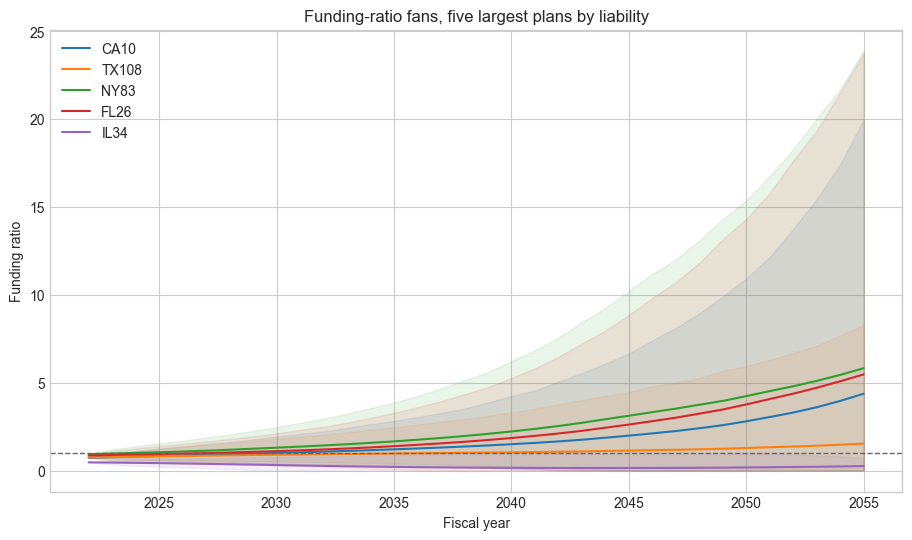

In [20]:
top_plans = plan_metrics.nlargest(5, "liability_billion")["plan"].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
for plan in top_plans:
    s = ra.forecast_summary(results[plan], graph_years=N_PROJ)
    line, = ax.plot(s["year"], s["mean"], label=plan)
    ax.fill_between(s["year"], s["q05"], s["q95"], alpha=0.10, color=line.get_color())
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title("Funding-ratio fans, five largest plans by liability")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Funding ratio")
ax.legend()
plt.show()

---
# Part 4: Cohort Structure (Per-Tier Decomposition)

The model divides each plan's active members into **tiers** — groups hired under
different benefit rules, created whenever a plan changed what it promised new
employees. Members hired before a reform stay on the old terms; members hired
after are on the new ones. Retirees already collecting benefits are carried as a
separate group again.

This section splits each plan's liability and benefit payments into those
groups. It answers questions the plan-level figures cannot: how much of what a
plan owes is owed to people already retired, how much to long-serving staff
under older and more generous terms, and how much to recent hires.

**Three things to be clear about before reading it.**

**Where the numbers come from.** The per-tier paths are saved in each plan's
deterministic result file but are *not* included in the parquet bundle the rest
of this notebook reads, so this section opens the result files directly. No
re-run is needed; the data has been there all along.

**These are hire-date groups, not birth cohorts.** A tier is defined by when
someone was hired and therefore which benefit rules apply to them, not by when
they were born. The two are related but they are not the same thing, and a tier
contains people of many ages. The latest tier boundary anywhere in the input
data is 1 July 2018, so nothing enacted since is represented.

**This decomposition is deterministic.** Each tier carries a single projected
path, not a distribution. Assets are simulated at the level of the whole plan,
so there is no simulated outcome belonging to one tier rather than another.
Turning this into a distribution *across* cohorts — which is what the project's
framing ultimately wants — requires deciding how a plan-level asset shortfall
should be attributed to the groups within it. That is a modelling decision, not
a plotting one, and it has not been taken.

Loaded per-tier paths for 40 plans; tier counts: [2, 3, 4, 5, 6, 7] groups per plan (including the already-retired group)


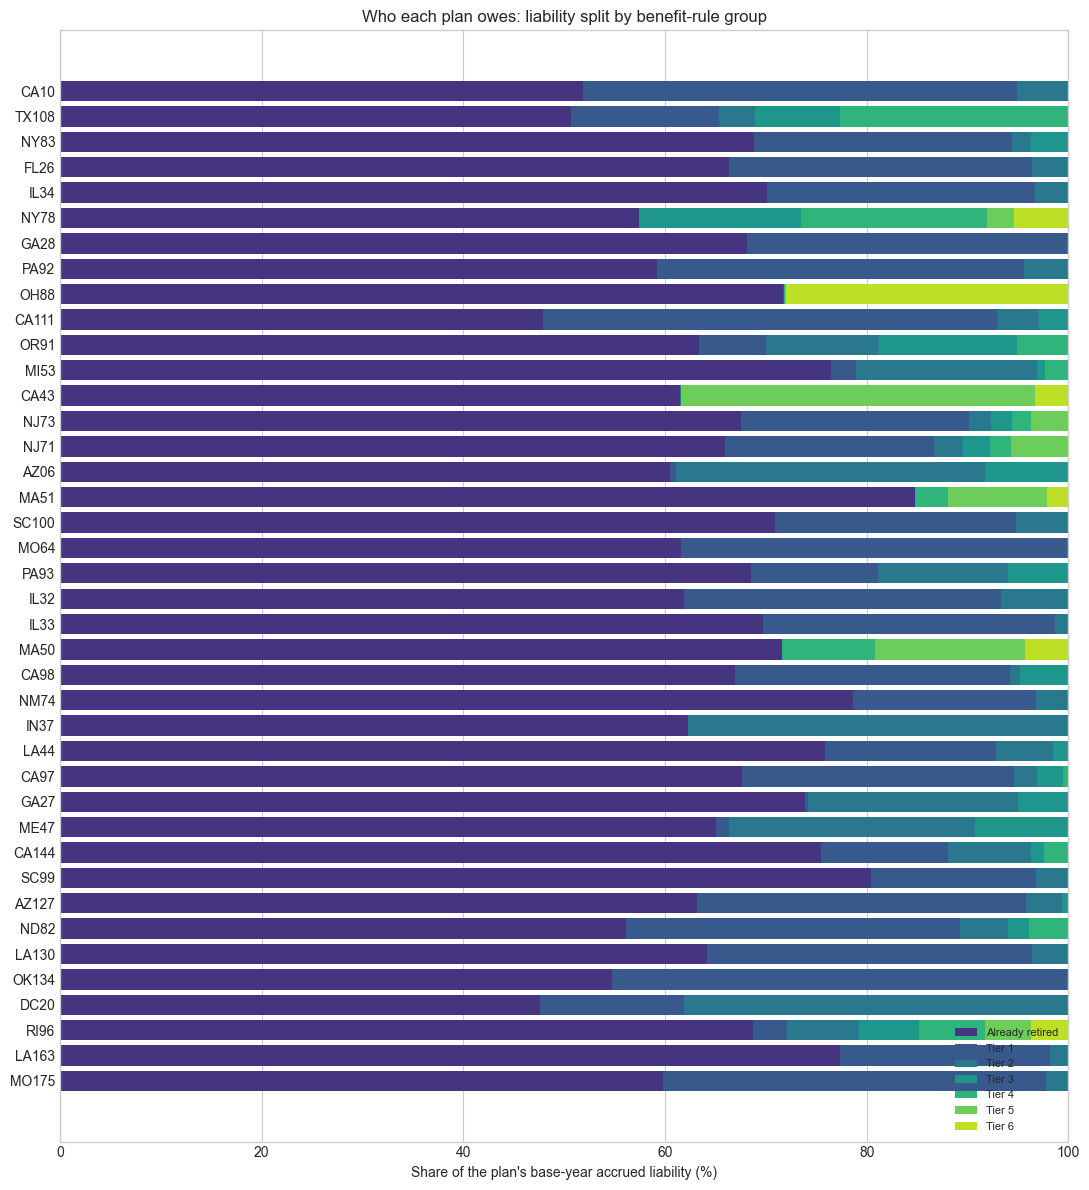

,aal_billion,share_of_all_plans
group,,
Already retired,1863.005,0.629
Tier 1,649.926,0.220
Tier 2,148.544,0.050
Tier 4,105.376,0.036
Tier 3,93.687,0.032
Tier 5,54.466,0.018
Tier 6,45.100,0.015


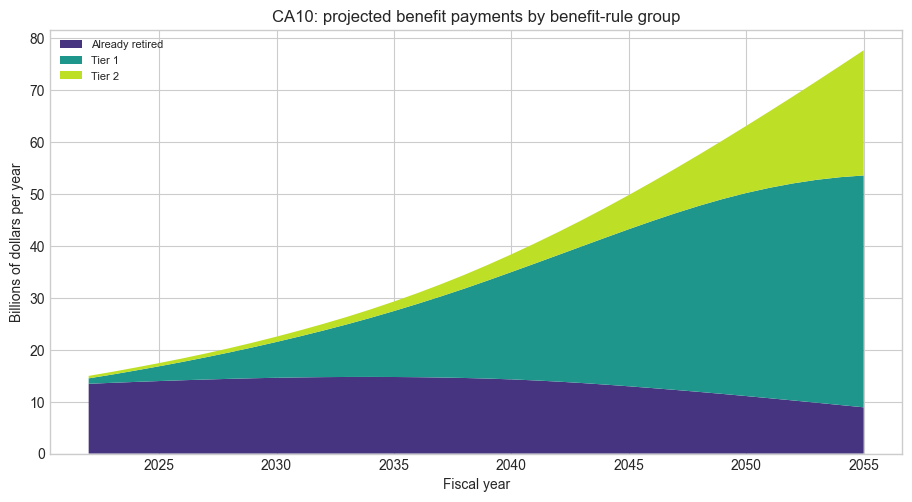

,plan,group,aal_billion,share
8,CA10,Tier 1,152.758,0.430
9,CA10,Tier 2,18.096,0.051
10,CA10,Already retired,184.298,0.519


In [21]:
import pickle as _pickle


def load_tier_paths(root, run_tag, plans):
    """Per-tier liability and benefit-outflow paths from the deterministic files.

    MainRes is keyed 1..6 by tier, each holding [AAL, outflow, inflow, PVFB, NC];
    RetRes holds [AAL, outflow] for members already retired at the base year.
    """
    out = {}
    for plan in plans:
        path = (Path(root) / "Results" / "Runs" / run_tag / plan
                / f"{plan}_detAL_{run_tag}.pkl")
        with path.open("rb") as handle:
            payload = _pickle.load(handle)
        groups = {}
        for tier, arrays in sorted(payload["MainRes"].items()):
            aal = np.asarray(arrays[0], dtype="float64").reshape(-1)
            outflow = np.asarray(arrays[1], dtype="float64").reshape(-1)
            if aal[0] > 0:                      # tiers with no members are all zero
                groups[f"Tier {tier}"] = {"aal": aal, "outflow": outflow}
        ret = payload["RetRes"]
        groups["Already retired"] = {
            "aal": np.asarray(ret[0], dtype="float64").reshape(-1),
            "outflow": np.asarray(ret[1], dtype="float64").reshape(-1),
        }
        # The parts must reconstruct the whole, or the decomposition is wrong.
        total = sum(g["aal"] for g in groups.values())
        saved = np.asarray(payload["AAL"], dtype="float64")[:, 0]
        if not np.allclose(total, saved, rtol=1e-9, atol=1.0):
            raise ValueError(f"{plan}: tier AALs do not sum to the saved total AAL.")
        out[plan] = groups
    return out


tier_paths = load_tier_paths(ROOT, RUN_TAG, sorted(results))
print(f"Loaded per-tier paths for {len(tier_paths)} plans; "
      f"tier counts: {sorted({len(v) for v in tier_paths.values()})} groups per plan "
      "(including the already-retired group)")

tier_rows = []
for plan, groups in tier_paths.items():
    total = sum(g["aal"][0] for g in groups.values())
    for name, g in groups.items():
        tier_rows.append({"plan": plan, "group": name,
                          "aal_billion": g["aal"][0] / 1e9,
                          "share": g["aal"][0] / total if total > 0 else np.nan})
tier_frame = pd.DataFrame(tier_rows)

order = plan_metrics.sort_values("liability_billion")["plan"].tolist()
pivot = (tier_frame.pivot_table(index="plan", columns="group", values="share")
         .reindex(order).fillna(0.0))
group_order = ["Already retired"] + [c for c in sorted(pivot.columns) if c != "Already retired"]
pivot = pivot[group_order]

fig, ax = plt.subplots(figsize=(12.5, max(6, len(pivot) * 0.30)))
left = np.zeros(len(pivot))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(group_order)))
for colour, name in zip(colors, group_order):
    ax.barh(pivot.index, pivot[name] * 100, left=left * 100, label=name, color=colour)
    left = left + pivot[name].to_numpy()
ax.set_xlabel("Share of the plan's base-year accrued liability (%)")
ax.set_title("Who each plan owes: liability split by benefit-rule group")
ax.set_xlim(0, 100)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8,
          title="Benefit-rule group", frameon=False)
plt.tight_layout()
plt.show()

aggregate_share = (tier_frame.groupby("group")["aal_billion"].sum()
                   .sort_values(ascending=False).to_frame("aal_billion"))
aggregate_share["share_of_all_plans"] = (aggregate_share["aal_billion"]
                                         / aggregate_share["aal_billion"].sum())
display(aggregate_share.round(3))

# --- benefit payments by group over time, largest plan ----------------------
big_plan = plan_metrics.nlargest(1, "liability_billion")["plan"].iloc[0]
groups = tier_paths[big_plan]
years_c = np.arange(BASE_YEAR, BASE_YEAR + N_PROJ)
fig, ax = plt.subplots(figsize=(11, 5.5))
stack = [groups[name]["outflow"][:N_PROJ] / 1e9 for name in group_order if name in groups]
labels = [name for name in group_order if name in groups]
ax.stackplot(years_c, *stack, labels=labels,
             colors=plt.cm.viridis(np.linspace(0.15, 0.9, len(labels))))
ax.set_title(f"{big_plan}: projected benefit payments by benefit-rule group")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Billions of dollars per year")
ax.legend(loc="upper left", fontsize=8)
plt.show()

display(tier_frame.loc[tier_frame["plan"] == big_plan].round(3))

---
# Part 5: Baseline Characteristics, Alternative Discounting, And Validation

## Summary Statistics

Baseline characteristics of the modeled plans using the GASB/PPD inputs saved with the result files — starting-condition measures, not simulated outcomes. `unweighted_mean` gives every plan equal weight; `weighted_mean` uses the natural denominator of each ratio (liabilities, payroll, retired members, active members). Ratios are computed only when the denominator is positive and finite. The second table shows the same core fields plan by plan, sorted from lowest to highest official funded ratio; dollar amounts in billions.

In [22]:
baseline_summary = table1_summary(plan_metrics)
display(baseline_summary.round(3))

core_plan_table = plan_metrics[[
    "plan", "PlanName", "official_funded_ratio", "unfunded_liabilities_payroll",
    "total_pension_contributions_payroll", "active_retired_members",
    "liability_billion", "unfunded_liability_billion", "n_simulations"
]].sort_values("official_funded_ratio")
display(core_plan_table.round(3))

,metric,unweighted_mean,unweighted_sd,unweighted_obs,weighted_mean,weighted_sd,weighted_obs
0,Assets / liabilities,0.752,0.158,40,0.755,0.158,40
1,Unfunded liabilities / payroll,2.149,1.616,40,1.797,1.449,40
2,Total pension contributions / payroll,0.386,0.270,40,0.286,0.137,40
3,Active members / retired members,1.163,0.279,40,1.225,0.332,40


,plan,PlanName,official_funded_ratio,unfunded_liabilities_payroll,total_pension_contributions_payroll,active_retired_members,liability_billion,unfunded_liability_billion,n_simulations
27,NJ73,New Jersey Teachers,0.421,3.654,0.443,1.419,72.609,42.054,10000
14,IL34,Illinois Teachers,0.438,6.921,0.606,1.240,143.524,80.613,10000
13,IL33,Illinois SERS,0.440,6.065,0.615,0.794,52.050,29.157,10000
26,NJ71,New Jersey PERS,0.534,2.632,0.344,1.262,67.502,31.453,10000
37,SC100,South Carolina RS,0.567,2.486,0.298,1.332,56.924,24.674,10000
15,IN37,Indiana Teachers,0.585,2.054,0.393,1.075,22.214,9.224,10000
20,MA51,Massachusetts Teachers,0.590,3.211,0.425,1.419,60.308,24.738,10000
34,PA92,Pennsylvania School Employees,0.617,2.981,0.417,1.006,114.477,43.830,10000
22,MI53,Michigan Public Schools,0.643,3.520,0.429,0.689,98.142,35.067,10000
38,SC99,South Carolina Police,0.654,2.192,0.326,1.277,9.093,3.145,10000


## Historical Official Funded Ratios

Historical official GASB funded ratios for the plans in the selected run: equal-weighted and liability-weighted by fiscal year. These are official accounting funded ratios, not AAA-discounted ratios.

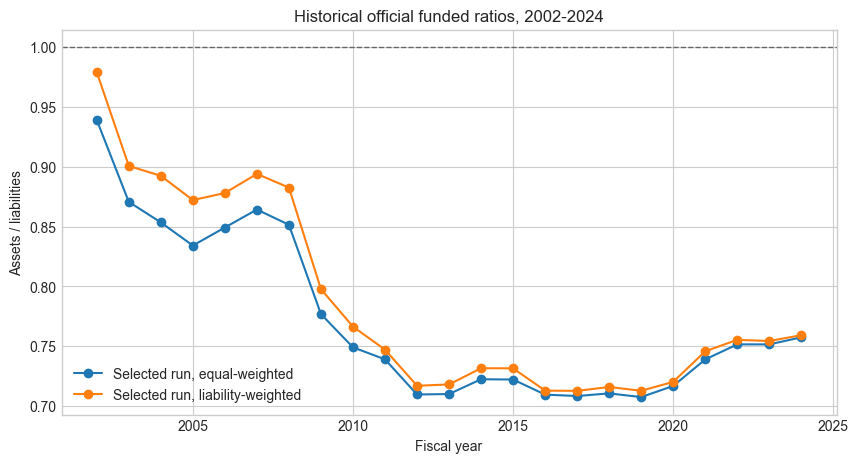

,fy,equal_weighted,liability_weighted,observations,weighted_observations
115,2015.0,0.722,0.731,40,40
116,2016.0,0.710,0.713,40,40
117,2017.0,0.708,0.713,40,40
118,2018.0,0.711,0.716,40,40
119,2019.0,0.707,0.713,40,40
120,2020.0,0.717,0.720,38,38
121,2021.0,0.739,0.746,40,40
122,2022.0,0.752,0.755,40,40
123,2023.0,0.752,0.754,40,40
124,2024.0,0.757,0.759,40,40


In [23]:
official_history = historical_official_funding(ppd, plan_metrics["ppid"].dropna().astype(int).tolist())
fig, ax = plt.subplots(figsize=(10, 5))
# Upper bound taken from the data rather than hardcoded: the PPD download in
# use reaches a later fiscal year than the 2023 that was pinned here before,
# and a hardcoded bound silently drops whatever the newer file added.
_last_fy = int(official_history["fy"].max())
plot_history = official_history.loc[official_history["fy"].between(2002, _last_fy)]
ax.plot(plot_history["fy"], plot_history["equal_weighted"], marker="o", label="Selected run, equal-weighted")
ax.plot(plot_history["fy"], plot_history["liability_weighted"], marker="o", label="Selected run, liability-weighted")
ax.axhline(1.0, color="0.4", linestyle="--", linewidth=1)
ax.set_title(f"Historical official funded ratios, 2002-{_last_fy}")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Assets / liabilities")
ax.legend()
plt.show()

display(plot_history.tail(10).round(3))

## AAA-Discounted Cash-Flow PV Funded Ratios

Discounts the projected benefit cash-outflow vectors saved in the deterministic result files at the base-year average AAA corporate bond yield from FRED. This is an exploratory cash-flow PV, not a full AAA actuarial accrued liability revaluation. Requires `FRED_API_KEY`; skips gracefully without it.

AAA rate source: FRED AAA, calendar-year 2022 average; rate used = 4.074%


,measure,assets_billion,denominator_billion,funded_ratio
0,Official GASB funded ratio,2132.484,2823.291,0.755
1,Model AAL funded ratio,2132.484,2960.104,0.720
2,AAA cash-flow PV funded ratio,2132.484,4739.756,0.450


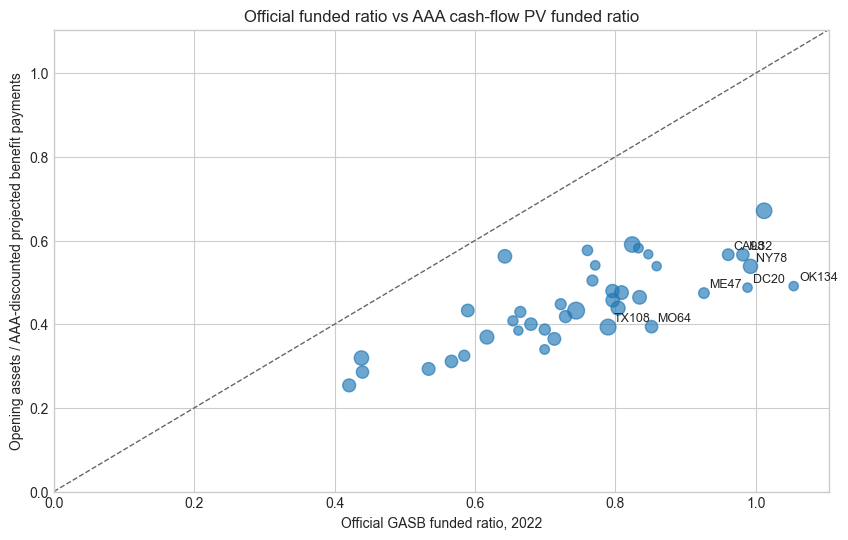

,plan,PlanName,official_funded_ratio,model_aal_funded_ratio,aaa_cashflow_pv_funded_ratio,opening_assets_billion,model_aal_billion,aaa_cashflow_pv_billion,plan_discount_rate
27,NJ73,New Jersey Teachers,0.421,0.405,0.254,30.555,75.442,120.398,0.070
13,IL33,Illinois SERS,0.440,0.394,0.286,22.893,58.070,80.144,0.068
26,NJ71,New Jersey PERS,0.534,0.476,0.293,36.049,75.717,122.994,0.070
37,SC100,South Carolina RS,0.567,0.550,0.311,32.250,58.636,103.689,0.070
14,IL34,Illinois Teachers,0.438,0.470,0.319,62.910,133.974,197.095,0.070
15,IN37,Indiana Teachers,0.585,0.455,0.325,12.990,28.552,40.013,0.062
25,ND82,North Dakota Teachers,0.699,0.583,0.340,3.133,5.370,9.223,0.072
0,AZ06,Arizona SRS,0.713,0.642,0.365,45.589,71.052,124.932,0.070
34,PA92,Pennsylvania School Employees,0.617,0.582,0.369,70.647,121.484,191.370,0.070
17,LA163,Baton Rouge City-Parish (LA) ERS,0.662,0.618,0.385,1.309,2.119,3.403,0.070


In [24]:
aaa_series = try_fetch_fred("AAA")

if aaa_series is None:
    print("AAA section skipped (no FRED data). Set FRED_API_KEY and rerun this cell.")
    aaa_pv = None
else:
    def base_year_average_rate(series, series_id, base_year):
        in_base_year = series.loc[series["date"].dt.year == base_year, series_id].dropna()
        if not in_base_year.empty:
            return float(in_base_year.mean()) / 100, f"calendar-year {base_year} average"
        through = series.loc[series["date"] <= pd.Timestamp(base_year, 12, 31), ["date", series_id]].dropna()
        if through.empty:
            raise ValueError(f"No {series_id} observations are available through {base_year}.")
        last = through.iloc[-1]
        return float(last[series_id]) / 100, f"last observation through {base_year}: {last['date'].date()}"

    def present_value_cashflows(cashflows, annual_rate):
        cashflows = np.asarray(cashflows, dtype="float64")
        periods = np.arange(1, cashflows.size + 1, dtype="float64")
        valid = np.isfinite(cashflows) & (cashflows > 0)
        return float(np.sum(cashflows[valid] / ((1 + annual_rate) ** periods[valid])))

    def aaa_cashflow_pv_summary(results, plan_metrics, aaa_rate):
        metric_lookup = plan_metrics.set_index("plan")
        rows = []
        for plan, result in sorted(results.items()):
            cashflows = result.matrix("cash_outflows").iloc[:, 0].to_numpy(dtype="float64")
            base_assets = float(result.matrix("Assets").iloc[0, 0])
            model_aal = float(result.matrix("AAL").iloc[0, 0])
            plan_discount_rate = float(result.scalars.get("discountrate", np.nan))
            aaa_pv_value = present_value_cashflows(cashflows, aaa_rate)
            rows.append({
                "plan": plan,
                "PlanName": metric_lookup.loc[plan, "PlanName"] if plan in metric_lookup.index else np.nan,
                "official_funded_ratio": metric_lookup.loc[plan, "official_funded_ratio"] if plan in metric_lookup.index else np.nan,
                "official_liability_billion": metric_lookup.loc[plan, "liability_billion"] if plan in metric_lookup.index else np.nan,
                "opening_assets_billion": base_assets / 1_000_000_000,
                "model_aal_billion": model_aal / 1_000_000_000,
                "aaa_cashflow_pv_billion": aaa_pv_value / 1_000_000_000,
                "plan_discount_rate": plan_discount_rate,
                "model_aal_funded_ratio": base_assets / model_aal if model_aal > 0 else np.nan,
                "aaa_cashflow_pv_funded_ratio": base_assets / aaa_pv_value if aaa_pv_value > 0 else np.nan,
            })
        return pd.DataFrame(rows)

    aaa_rate, aaa_rate_basis = base_year_average_rate(aaa_series, "AAA", BASE_YEAR)
    aaa_pv = aaa_cashflow_pv_summary(results, plan_metrics, aaa_rate)

    aggregate_aaa = pd.DataFrame([
        {"measure": "Official GASB funded ratio",
         "assets_billion": num_col(plan_metrics, "ActAssets_GASB").sum() / 1_000_000,
         "denominator_billion": num_col(plan_metrics, "ActLiabilities_GASB").sum() / 1_000_000,
         "funded_ratio": num_col(plan_metrics, "ActAssets_GASB").sum() / num_col(plan_metrics, "ActLiabilities_GASB").sum()},
        {"measure": "Model AAL funded ratio",
         "assets_billion": aaa_pv["opening_assets_billion"].sum(),
         "denominator_billion": aaa_pv["model_aal_billion"].sum(),
         "funded_ratio": aaa_pv["opening_assets_billion"].sum() / aaa_pv["model_aal_billion"].sum()},
        {"measure": "AAA cash-flow PV funded ratio",
         "assets_billion": aaa_pv["opening_assets_billion"].sum(),
         "denominator_billion": aaa_pv["aaa_cashflow_pv_billion"].sum(),
         "funded_ratio": aaa_pv["opening_assets_billion"].sum() / aaa_pv["aaa_cashflow_pv_billion"].sum()},
    ])
    print(f"AAA rate source: FRED AAA, {aaa_rate_basis}; rate used = {aaa_rate:.3%}")
    display(aggregate_aaa.round(3))

    plot_df = aaa_pv.dropna(subset=["official_funded_ratio", "aaa_cashflow_pv_funded_ratio", "official_liability_billion"])
    fig, ax = plt.subplots(figsize=(10, 6))
    sizes = 35 + 6 * np.sqrt(plot_df["official_liability_billion"].clip(lower=0))
    ax.scatter(plot_df["official_funded_ratio"], plot_df["aaa_cashflow_pv_funded_ratio"], s=sizes, alpha=0.65)
    limit = max(plot_df["official_funded_ratio"].max(), plot_df["aaa_cashflow_pv_funded_ratio"].max()) + 0.05
    ax.plot([0, limit], [0, limit], color="0.4", linestyle="--", linewidth=1)
    for _, row in plot_df.assign(gap=lambda x: x["official_funded_ratio"] - x["aaa_cashflow_pv_funded_ratio"]).sort_values("gap", ascending=False).head(8).iterrows():
        ax.annotate(row["plan"], (row["official_funded_ratio"], row["aaa_cashflow_pv_funded_ratio"]), fontsize=9, xytext=(4, 4), textcoords="offset points")
    ax.set_title("Official funded ratio vs AAA cash-flow PV funded ratio")
    ax.set_xlabel(f"Official GASB funded ratio, {BASE_YEAR}")
    ax.set_ylabel("Opening assets / AAA-discounted projected benefit payments")
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    plt.show()

    display(
        aaa_pv[["plan", "PlanName", "official_funded_ratio", "model_aal_funded_ratio",
                "aaa_cashflow_pv_funded_ratio", "opening_assets_billion", "model_aal_billion",
                "aaa_cashflow_pv_billion", "plan_discount_rate"]]
        .sort_values("aaa_cashflow_pv_funded_ratio")
        .round(3)
    )

## Model Liability Validation Against CAFR AAL

Compares the model's saved AAL estimate with the official CAFR/GASB AAL recorded in the result file. Points far from the 45-degree line indicate plans where the model liability differs materially from the reported liability. The histogram shows the percent-difference diagnostic across plans.

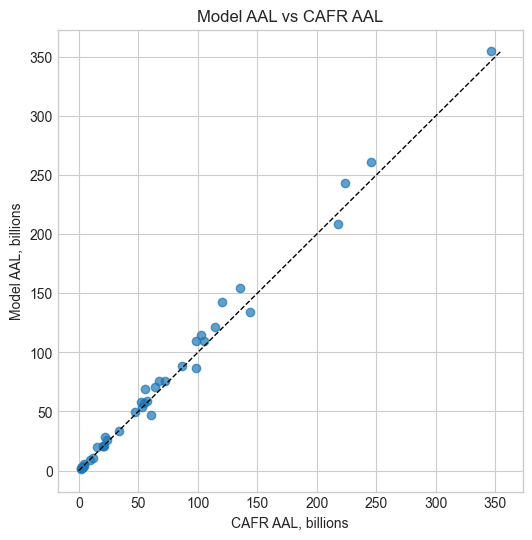

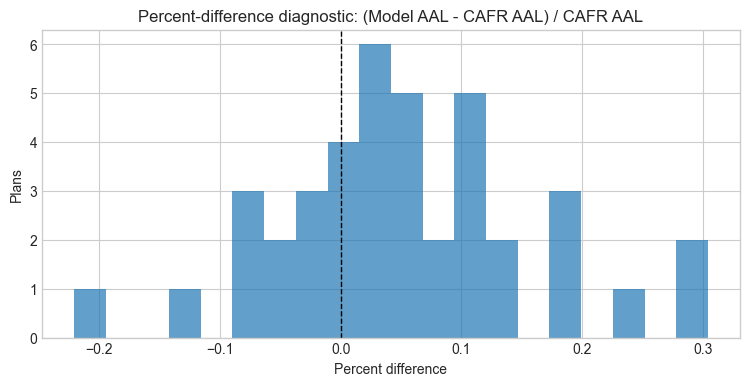

,plan,PlanName,model_aal_billion,cafr_aal_billion,percent_difference
20,MA51,Massachusetts Teachers,46.981,60.308,-0.221
22,MI53,Michigan Public Schools,86.506,98.142,-0.119
4,CA144,San Diego (CA) ERS,10.963,11.848,-0.075
14,IL34,Illinois Teachers,133.974,143.524,-0.067
1,AZ127,Arizona State Corrections Officers,4.296,4.594,-0.065
16,LA130,Louisiana Municipal Police,3.301,3.449,-0.043
9,FL26,Florida RS,208.755,217.434,-0.040
23,MO175,Kansas City (MO) ERS,1.442,1.492,-0.034
36,RI96,Rhode Island Municipal,2.245,2.290,-0.019
18,LA44,Louisiana SERS,20.503,20.798,-0.014


In [25]:
validation = plan_metrics.dropna(subset=["model_aal_billion", "cafr_aal_billion"])[["plan", "PlanName", "model_aal_billion", "cafr_aal_billion", "percent_difference"]].copy()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(validation["cafr_aal_billion"], validation["model_aal_billion"], alpha=0.7)
limit = max(validation["cafr_aal_billion"].max(), validation["model_aal_billion"].max())
ax.plot([0, limit], [0, limit], color="black", linestyle="--", linewidth=1)
ax.set_title("Model AAL vs CAFR AAL")
ax.set_xlabel("CAFR AAL, billions")
ax.set_ylabel("Model AAL, billions")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validation["percent_difference"].dropna(), bins=20, alpha=0.7)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Percent-difference diagnostic: (Model AAL - CAFR AAL) / CAFR AAL")
ax.set_xlabel("Percent difference")
ax.set_ylabel("Plans")
plt.show()

display(validation.sort_values("percent_difference").round(3))

---
# Items Requiring New Scenario Runs

The current result files support everything above. The following require new simulation scenarios, not more post-processing:

- **Contribution-policy counterfactuals:** the permanent contribution increase needed to hit target exhaustion probabilities (for example 0.5%, 1%, 3%) requires rerunning the asset stage with an explicit contribution-policy parameter. At `num_sim = 10000` the probability grid (0.01 percentage points) is fine enough; the missing piece is the policy lever in the simulation, not precision.
- **Waiting-period stabilization scenarios:** permanent contribution increases starting immediately versus after 5, 10, or 15 years — same policy engine as above, plus a start-delay parameter.
- **Investment-strategy counterfactuals:** reruns under alternative asset allocations or return assumptions (for example de-risking paths). The shared market-shock matrix makes these directly comparable path-by-path: the same market history can be replayed under each policy.
- **Model-consistent AAA liability revaluation:** recomputing AAL with an AAA discount rate inside the liability model (not just discounting projected cash flows, as in the exploratory section above).
- **Tier-level reform comparison (planned rework):** the earlier descriptive reform section was removed; the replacement should compare each plan's pre-change versus post-change tier provisions directly (matched to the model's tier structure), rather than the earliest-vs-latest workbook diff used before.
- **No-reform counterfactuals:** rerunning the liability model with pre-reform benefit rules for plans that changed tiers after 2007, to quantify what reforms saved.

Check the run manifest at the top before using tables as final results; rerun any missing plan outputs first.